#Library & Collecting Data

In [1]:
try:
    from unsloth import FastLanguageModel
except ImportError:
    !pip install unsloth
    !pip install --no-deps xformers trl peft accelerate bitsandbytes
    from unsloth import FastLanguageModel

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


Tahap ini berfungsi untuk menginstal dan mengimpor library `unsloth` yang dioptimalkan untuk menjalankan model bahasa besar (LLM) secara efisien di Colab. Tujuannya agar mampu melakukan penjelasan medis menggunakan AI generatif di akhir proyek. Langkah selanjutnya adalah mengimpor library standar untuk pengolahan data dan visualisasi.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import skew
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

from google.colab import drive, userdata
drive.mount('/content/drive')

Mounted at /content/drive


Cell ini mengimpor semua library yang diperlukan mulai dari `pandas` untuk manipulasi tabel hingga `scikit-learn` untuk pemodelan machine learning. Selain itu, dilakukan mounting Google Drive untuk mengakses dataset yang disimpan secara eksternal. Setelah library siap, kita akan memuat dataset utama ke dalam dataframe.

In [7]:
drive_file_path = '/content/drive/MyDrive/Colab Notebooks/Dataset/train.csv'
df = pd.read_csv(drive_file_path, sep=';')

Kode ini membaca file `train.csv` dari Google Drive menggunakan pemisah titik koma untuk diubah menjadi DataFrame pandas. Tujuannya adalah memasukkan data mentah ke dalam memori agar bisa dianalisis lebih lanjut. Langkah berikutnya adalah melakukan eksplorasi awal untuk memahami struktur dan tipe data yang ada.

#Data Information

In [8]:
df.head()

,id,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,1,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,2,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,3,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,4,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,5,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Di sini saya mau melihat isi dari tabel train ini.

In [9]:
df.describe()

,id,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000
mean,461.389646,53.651226,133.064033,199.683924,0.227520,136.178474,0.905041,0.546322
std,267.255825,9.364290,18.438941,108.216855,0.419517,25.329254,1.082952,0.498189
min,1.000000,29.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,227.500000,47.000000,120.000000,177.000000,0.000000,118.000000,0.000000,0.000000
50%,461.500000,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,693.750000,60.000000,140.000000,269.000000,0.000000,155.000000,1.500000,1.000000
max,918.000000,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Dapat terlihat disini bahwa beberapa fitur memiliki nilai yang berskala tinggi dan rendah. dapat dilihat juga fitur cholesterol dan restingBP memiliki niali terkecil 0, padahal tidak memungkinkan faktor ini memiliki nilai 0. RestingBP tidak bisa 0 karena pasien masih hidup. Sedangkan, kolesterol tidak bisa 0 karena dibutuhkan untuk organ-organ manusia menjalankan fungsinya.

Fitur kolesterol juga harus dicurigai karena mean sangat jauh terhadap nilai tertinggi, kemudian standar deviasi juga cukup tinggi sehingga perlu dicurigai. FastingBS juga bernilai 1 dan 0 berarti merupakan nilai biner iya atau tidak.

In [10]:
non_kol_angka = df.select_dtypes(include=['object'])

for col in non_kol_angka.columns:
    print(f"Unique values in '{col}':")
    print(df[col].unique())
    print("\n")

Unique values in 'Sex':
['M' 'F']


Unique values in 'ChestPainType':
['ATA' 'NAP' 'ASY' 'TA']


Unique values in 'RestingECG':
['Normal' 'ST' 'LVH']


Unique values in 'ExerciseAngina':
['N' 'Y']


Unique values in 'ST_Slope':
['Up' 'Flat' 'Down']




Di sini saya melihat beberapa unique value berisikan paling banyak 4 value unik yaitu ChestPainType dan paling sedikit 2 value unik yaitu Sex, ExcerciseAngina.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              734 non-null    int64  
 1   Age             734 non-null    int64  
 2   Sex             734 non-null    object 
 3   ChestPainType   734 non-null    object 
 4   RestingBP       734 non-null    int64  
 5   Cholesterol     734 non-null    int64  
 6   FastingBS       734 non-null    int64  
 7   RestingECG      734 non-null    object 
 8   MaxHR           734 non-null    int64  
 9   ExerciseAngina  734 non-null    object 
 10  Oldpeak         734 non-null    float64
 11  ST_Slope        734 non-null    object 
 12  HeartDisease    734 non-null    int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 74.7+ KB


Tahap ini menggunakan df.info() untuk mengecek jumlah baris, kolom, tipe data, serta keberadaan nilai non-null pada dataset. Tujuannya adalah memastikan apakah ada tipe data yang perlu diubah seperti kategori ke numerik sebelum masuk ke tahap pembersihan. Selanjutnya, kita akan mendeteksi nilai kosong secara spesifik.

In [12]:
df.isnull().sum()

,0
id,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0


Dapat dilihat tidak ada nilai kosong atau nilai NaN di dalam tabel ini.

In [13]:
df.duplicated().sum()

np.int64(0)

Di sini tidak ditemukan baris yang duplikat.

#Data Cleaning + Exploratory Data Analysis

In [14]:
# Hapus Fitur non-Relevan
df=df.drop(columns='id')

Di sini saya menghapus fitur id karena tidak diperlukan untuk melatih model.

In [15]:
# Mengubah data 0 pada kolesterol dan restingBP menjadi NaN
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
df['RestingBP'] = df['RestingBP'].replace(0, np.nan)

print("Jumlah perubahan angka 0:")
print(df[['Cholesterol', 'RestingBP']].isnull().sum())

Jumlah perubahan angka 0:
Cholesterol    137
RestingBP        1
dtype: int64


Pada tahap ini, nilai '0' yang tidak logis pada kolom *Cholesterol* dan *RestingBP* diubah menjadi `NaN`. Hal ini dilakukan karena secara medis kadar kolesterol nol tidak mungkin terjadi sehingga harus ditandai sebagai data hilang agar tidak merusak perhitungan statistik. Langkah selanjutnya adalah mencoba berbagai metode imputasi untuk mengisi nilai kosong tersebut.

In [16]:
# copy kedua tabel
med_df = df.copy()
mea_df = df.copy()
mic_df = df.copy()

### Percobaan 1: Imputasi dengan median

In [17]:
# mengisi data yang NaN pada kolesterol dan restingBP dengan median masing-masing fitur
med_df['Cholesterol'] = med_df['Cholesterol'].fillna(med_df['Cholesterol'].median())
med_df['RestingBP'] = med_df['RestingBP'].fillna(med_df['RestingBP'].median())

print("Jumlah NaN yang tersisa:")
print(med_df[['Cholesterol', 'RestingBP']].isnull().sum())

med_kol_angka = med_df.select_dtypes(include=['int64', 'float64'])

med_df.describe()

Jumlah NaN yang tersisa:
Cholesterol    0
RestingBP      0
dtype: int64


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000
mean,53.651226,133.241144,243.919619,0.227520,136.178474,0.905041,0.546322
std,9.364290,17.771335,50.588222,0.419517,25.329254,1.082952,0.498189
min,29.000000,94.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,215.000000,0.000000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,237.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,269.000000,0.000000,155.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Di sini saya menyediakan imputasi median karena membutuhkan pengisian data dari missing value tetapi distribusi data belum normal sehingga distribusi data lebih mendekati normal.

### Percobaan 2: Imputasi dengan Mean

In [18]:
# mengisi data yang NaN pada kolesterol dan restingBP dengan mean masing-masing fitur
mea_df['Cholesterol'] = mea_df['Cholesterol'].fillna(mea_df['Cholesterol'].mean())
mea_df['RestingBP'] = mea_df['RestingBP'].fillna(mea_df['RestingBP'].mean())

print("Jumlah NaN yang tersisa:")
print(mea_df[['Cholesterol', 'RestingBP']].isnull().sum())

mea_kol_angka = mea_df.select_dtypes(include=['int64', 'float64'])

mea_df.describe()

Jumlah NaN yang tersisa:
Cholesterol    0
RestingBP      0
dtype: int64


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000
mean,53.651226,133.245566,245.507538,0.227520,136.178474,0.905041,0.546322
std,9.364290,17.770931,50.479356,0.419517,25.329254,1.082952,0.498189
min,29.000000,94.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,215.000000,0.000000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,245.507538,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,269.000000,0.000000,155.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Di sini saya menyediakan imputasi mean karena membutuhkan pengisian data dari missing value tetapi distribusi data sudah normal.

### Percobaan 3: Iterative Imputer (MICE)


In [19]:
# mengisi data yang NaN pada kolesterol dan restingBP dengan MICE masing-masing fitur
imputer = IterativeImputer(max_iter=10, random_state=0)
kolom_imputasi = ['RestingBP', 'Cholesterol']

mic_df[kolom_imputasi] = imputer.fit_transform(mic_df[kolom_imputasi])

print("Jumlah NaN yang tersisa:")
print(mic_df[['Cholesterol', 'RestingBP']].isnull().sum())

mic_kol_angka = mic_df.select_dtypes(include=['int64', 'float64'])

mic_df.describe()

Jumlah NaN yang tersisa:
Cholesterol    0
RestingBP      0
dtype: int64


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000,734.000000
mean,53.651226,133.245566,245.468772,0.227520,136.178474,0.905041,0.546322
std,9.364290,17.770931,50.549820,0.419517,25.329254,1.082952,0.498189
min,29.000000,94.000000,85.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,215.000000,0.000000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,243.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,269.000000,0.000000,155.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Tahap ini menerapkan metode Multivariate Imputation by Chained Equations (MICE) untuk mengisi nilai yang hilang berdasarkan pola dari fitur lainnya. Tujuannya adalah mendapatkan estimasi nilai yang lebih akurat dibandingkan hanya menggunakan rata-rata sederhana. Setelah imputasi selesai, kita akan memvalidasi hasilnya melalui visualisasi boxplot dan distribusi.

###Boxplot

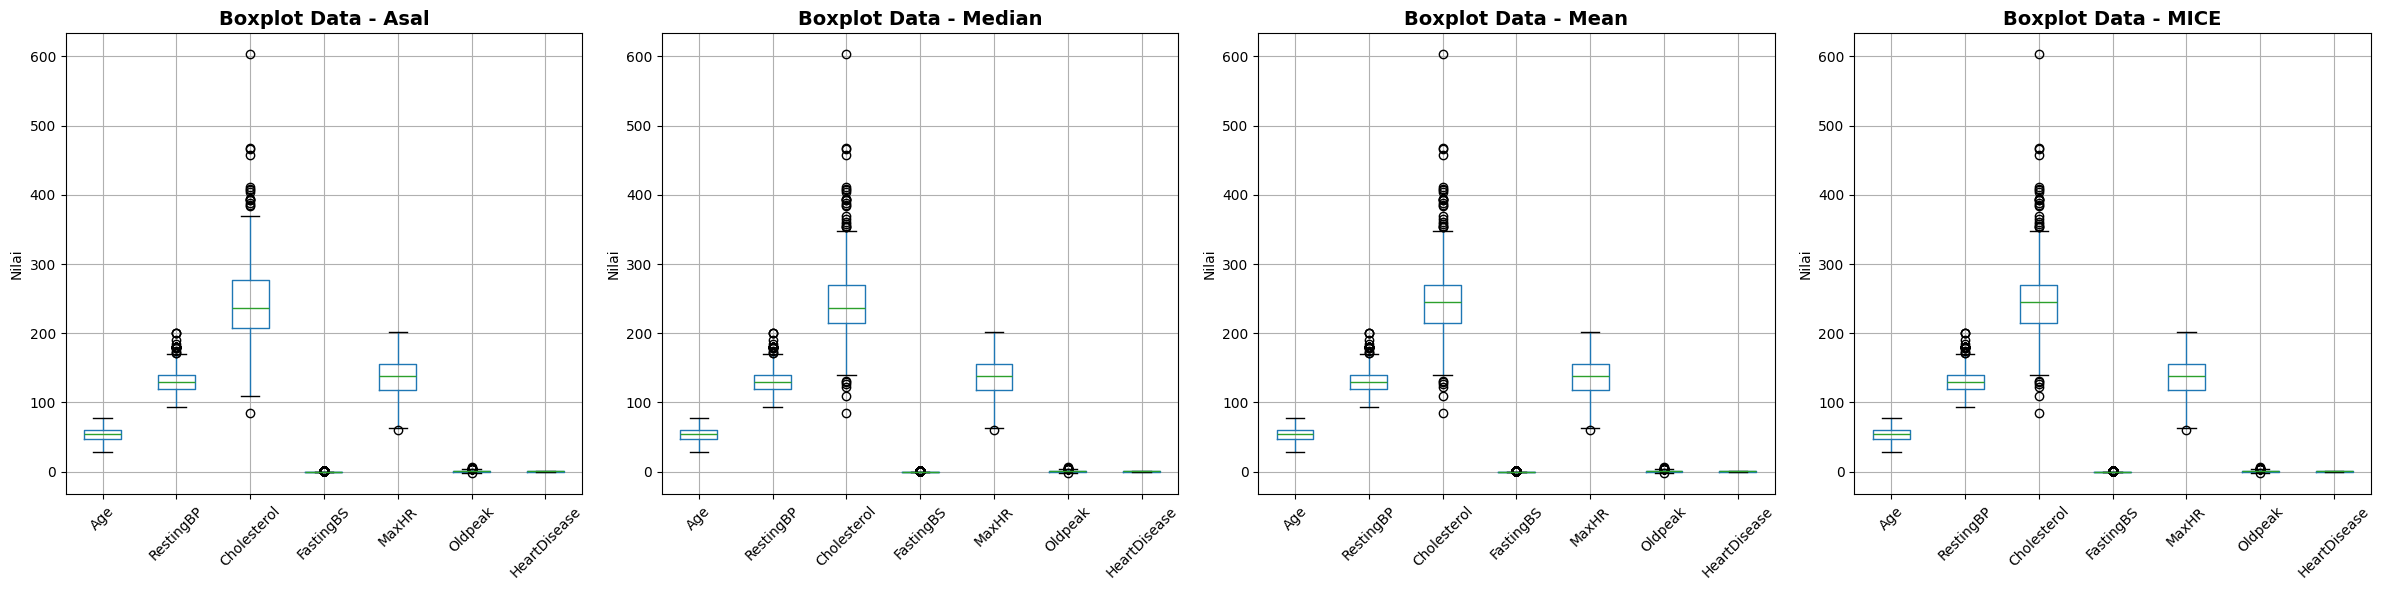

In [20]:
# Melihat Persebaran outlier dengan boxplot
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

kol_angka = df.select_dtypes(include=['int64', 'float64'])

df.boxplot(ax=axes[0])
axes[0].set_title('Boxplot Data - Asal', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nilai')
axes[0].set_xticklabels(kol_angka.columns, rotation=45)
axes[0].grid(True)

med_df.boxplot(ax=axes[1])
axes[1].set_title('Boxplot Data - Median', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Nilai')
axes[1].set_xticklabels(med_kol_angka.columns, rotation=45)
axes[1].grid(True)

mea_df.boxplot(ax=axes[2])
axes[2].set_title('Boxplot Data - Mean', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Nilai')
axes[2].set_xticklabels(mea_kol_angka.columns, rotation=45)
axes[2].grid(True)

mea_df.boxplot(ax=axes[3])
axes[3].set_title('Boxplot Data - MICE', fontsize=14, fontweight='bold')
axes[3].set_ylabel('Nilai')
axes[3].set_xticklabels(mic_kol_angka.columns, rotation=45)
axes[3].grid(True)

plt.tight_layout()
plt.show()

Visualisasi boxplot digunakan untuk mendeteksi keberadaan outlier pada fitur numerik. Dari grafik di atas, terlihat bahwa Kolesterol memiliki jumlah outlier yang sangat signifikan di sisi atas atau bernilai tinggi. Hal ini wajar dalam konteks medis karena kondisi hiperkolesterolemia. Salah satu metode imputasi Median cenderung mempertahankan struktur outlier asli, sementara Imputasi Mean sedikit menarik pusat data ke arah rata-rata.


### Variansi Kolesterol

In [21]:
#Melihat variansi dari data kolesterol
print("Varians Data Kolesterol Asli :", df['Cholesterol'].var())
print("Varians Data Kolesterol Median :", med_df['Cholesterol'].var())
print("Varians Data Kolesterol Mean   :", mea_df['Cholesterol'].var())
print("Varians Data Kolesterol MICE   :", mic_df['Cholesterol'].var())

Varians Data Kolesterol Asli : 3133.901369262422
Varians Data Kolesterol Median : 2559.1681548338224
Varians Data Kolesterol Mean   : 2548.1653698231944
Varians Data Kolesterol MICE   : 2555.284269941539


Variansi mengukur seberapa jauh penyebaran data dari nilai rata-ratanya. Data asli memiliki variansi tertinggi karena adanya nilai '0' yang dianggap ekstrem setelah diubah menjadi NaN. Pengisian nilai kosong dengan imputasi menyebabkan penurunan variansi. MICE dan Median memberikan variansi yang lebih tinggi dibandingkan Mean yang menunjukkan bahwa kedua metode tersebut lebih baik dalam mempertahankan keragaman data dibandingkan pengisian dengan nilai mean yang cenderung membuat data menjadi terlalu seragam.

### Correlation Heatmap

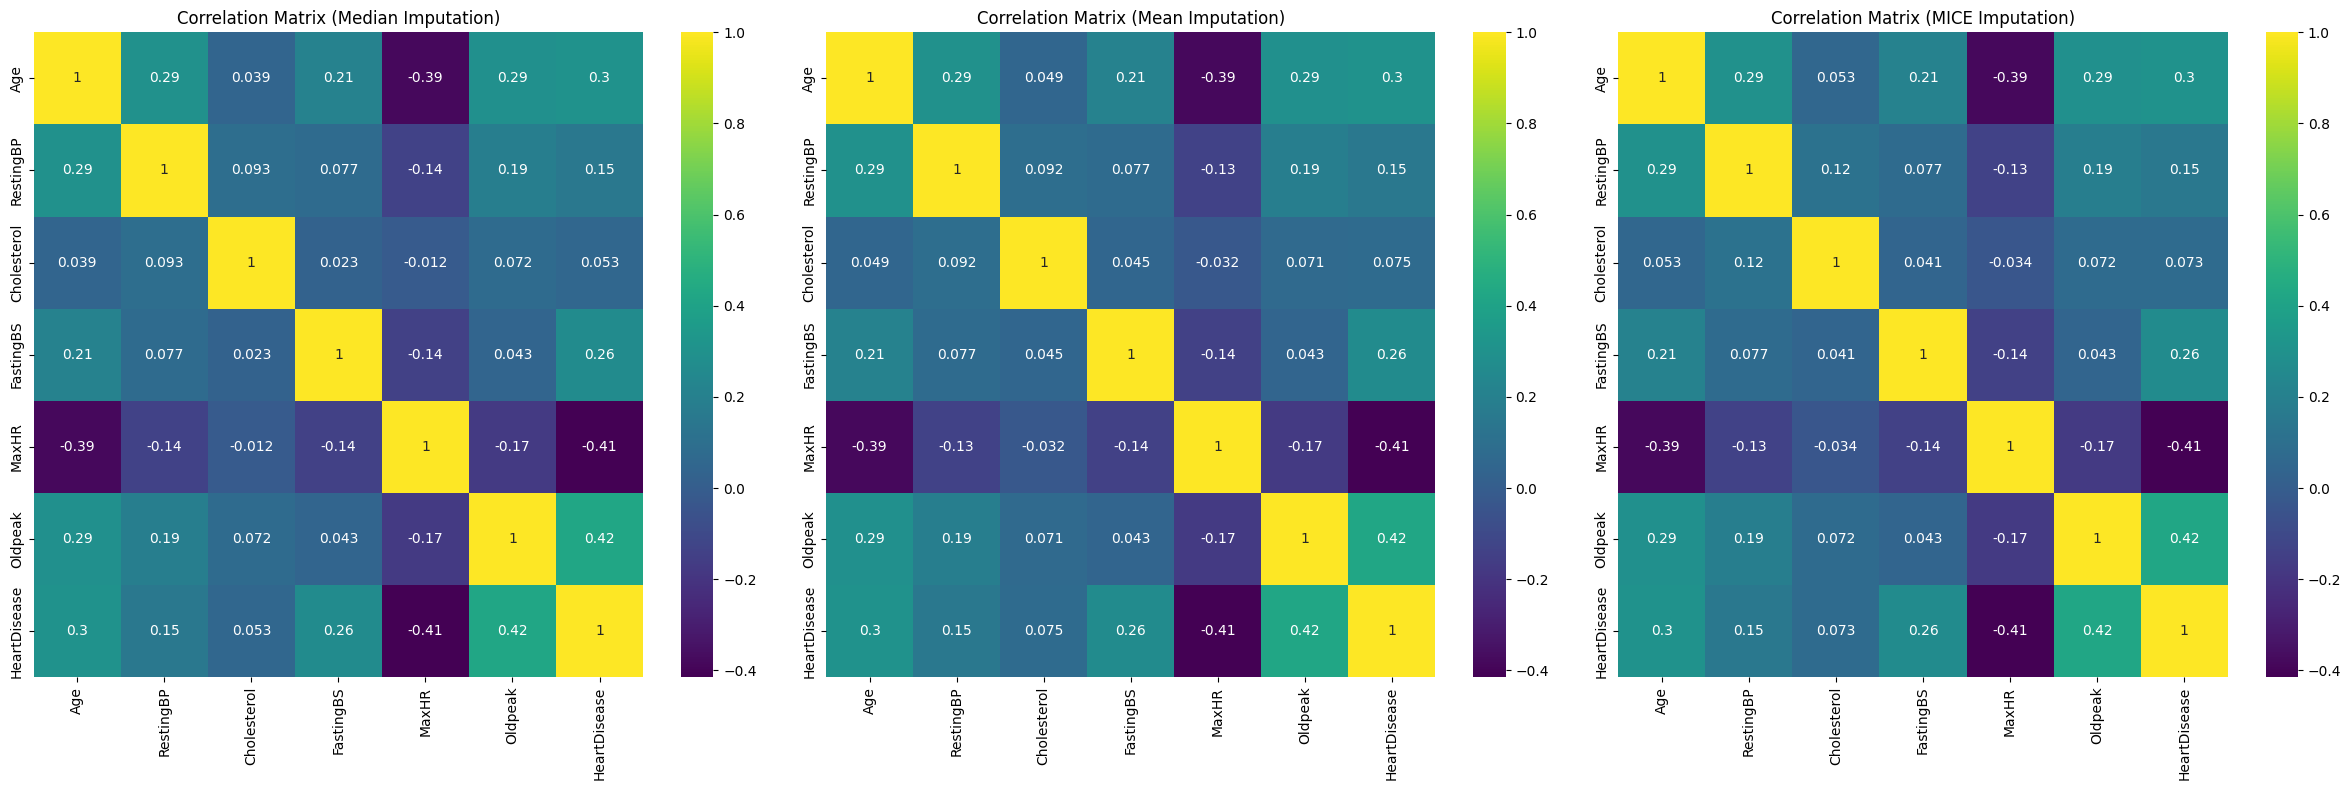

In [22]:
# melihat korelasi antar fitur angka
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

sns.heatmap(med_kol_angka.corr(), annot=True, ax=axes[0], cmap='viridis')
axes[0].set_title('Correlation Matrix (Median Imputation)')

sns.heatmap(mea_kol_angka.corr(), annot=True, ax=axes[1], cmap='viridis')
axes[1].set_title('Correlation Matrix (Mean Imputation)')

sns.heatmap(mic_kol_angka.corr(), annot=True, ax=axes[2], cmap='viridis')
axes[2].set_title('Correlation Matrix (MICE Imputation)')

plt.tight_layout()
plt.show()

Heatmap ini menunjukkan hubungan linear antar fitur numerik. Fitur `Oldpeak` dan `MaxHR` seringkali menunjukkan korelasi yang lebih tinggi terhadap target `HeartDisease`. Korelasi antar fitur independen yang rendah di bawah 0.8 menandakan tidak adanya masalah sehingga model regresi dapat bekerja dengan stabil.

### Skewness

In [23]:
# melihat kemiringan setiap fitur angka. Jika lebih dari -0.5 sampai 0.5 maka tidak terdistribusi normal
sk_asl = kol_angka.apply(lambda x: skew(x.dropna()))
sk_med = med_kol_angka.apply(lambda x: skew(x.dropna()))
sk_mea = mea_kol_angka.apply(lambda x: skew(x.dropna()))
sk_mic = mic_kol_angka.apply(lambda x: skew(x.dropna()))

df_skewness = pd.concat([sk_asl, sk_med, sk_mea, sk_mic], axis=1)
df_skewness.columns = ['Skew Asli', 'Skew Median', 'Skew Mean', 'Skew MICE']

df_skewness

,Skew Asli,Skew Median,Skew Mean,Skew MICE
Age,-0.179737,-0.179737,-0.179737,-0.179737
RestingBP,0.632362,0.633488,0.632793,0.632793
Cholesterol,1.031192,1.229413,1.143406,1.141163
FastingBS,1.299901,1.299901,1.299901,1.299901
MaxHR,-0.164513,-0.164513,-0.164513,-0.164513
Oldpeak,1.044184,1.044184,1.044184,1.044184
HeartDisease,-0.186086,-0.186086,-0.186086,-0.186086


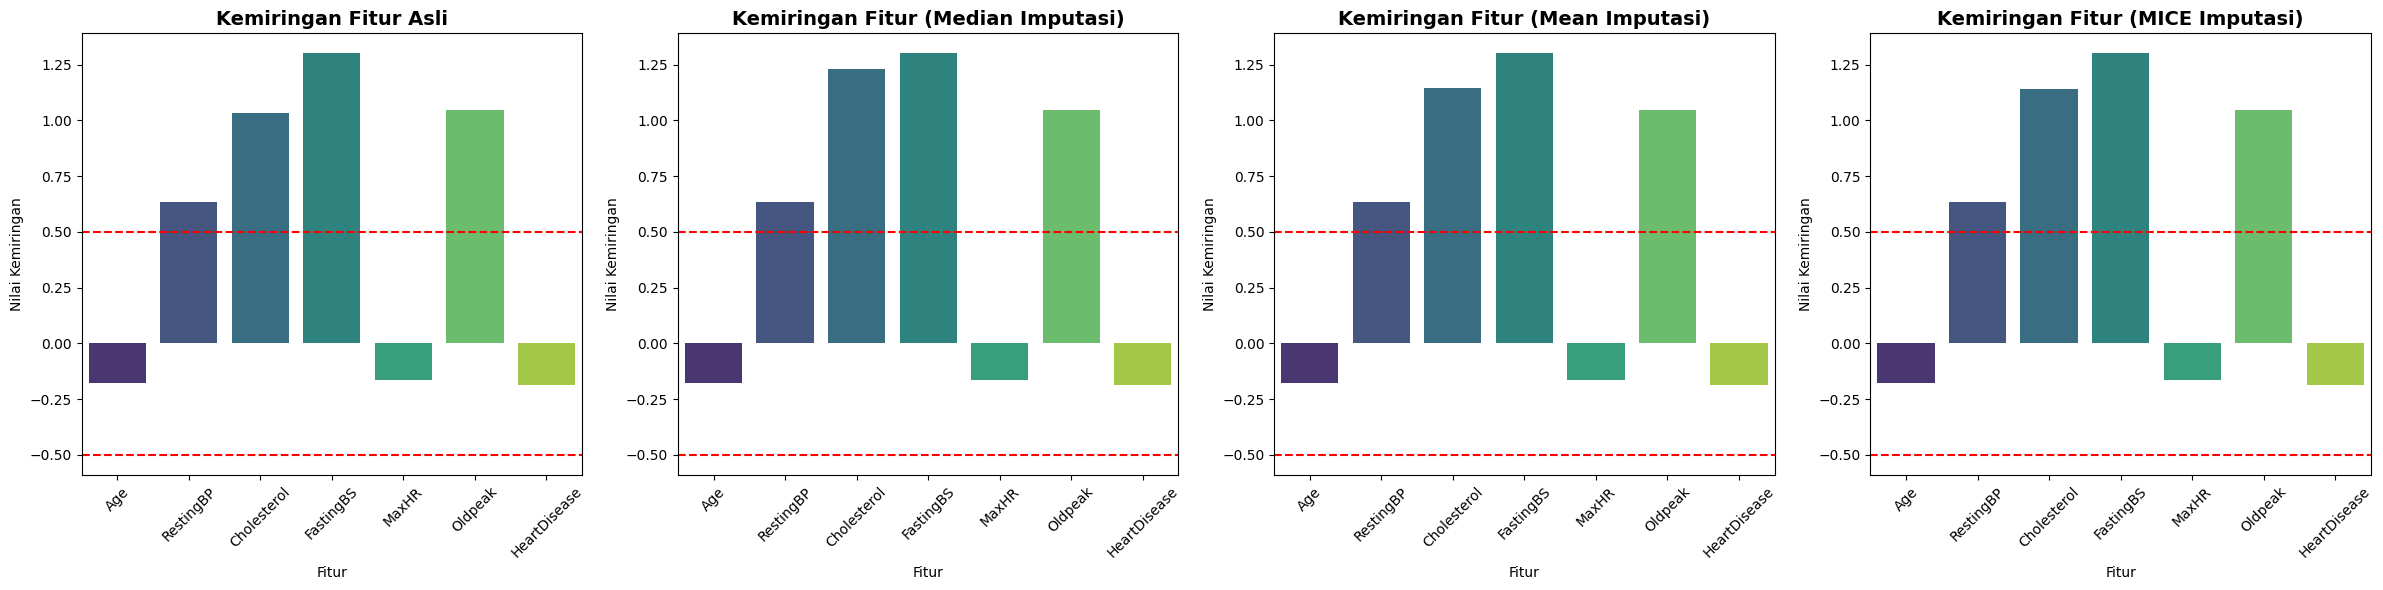

In [24]:
# melihat visualisasi kemiringan setiap fitur angka
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

sns.barplot(x=sk_asl.index, y=sk_asl.values, palette='viridis', ax=axes[0])
axes[0].set_title('Kemiringan Fitur Asli', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fitur')
axes[0].set_ylabel('Nilai Kemiringan')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(y=0.5, color='red', linestyle='--')
axes[0].axhline(y=-0.5, color='red', linestyle='--')

sns.barplot(x=sk_med.index, y=sk_med.values, palette='viridis', ax=axes[1])
axes[1].set_title('Kemiringan Fitur (Median Imputasi)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fitur')
axes[1].set_ylabel('Nilai Kemiringan')
axes[1].tick_params(axis='x', rotation=45)
axes[1].axhline(y=0.5, color='red', linestyle='--')
axes[1].axhline(y=-0.5, color='red', linestyle='--')

sns.barplot(x=sk_mea.index, y=sk_mea.values, palette='viridis', ax=axes[2])
axes[2].set_title('Kemiringan Fitur (Mean Imputasi)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Fitur')
axes[2].set_ylabel('Nilai Kemiringan')
axes[2].tick_params(axis='x', rotation=45)
axes[2].axhline(y=0.5, color='red', linestyle='--')
axes[2].axhline(y=-0.5, color='red', linestyle='--')

sns.barplot(x=sk_mic.index, y=sk_mic.values, palette='viridis', ax=axes[3])
axes[3].set_title('Kemiringan Fitur (MICE Imputasi)', fontsize=14, fontweight='bold')
axes[3].set_xlabel('Fitur')
axes[3].set_ylabel('Nilai Kemiringan')
axes[3].tick_params(axis='x', rotation=45)
axes[3].axhline(y=0.5, color='red', linestyle='--')
axes[3].axhline(y=-0.5, color='red', linestyle='--')

plt.tight_layout()
plt.show()

Skewness mengukur asimetri distribusi data. Rentang ideal untuk distribusi normal adalah antara -0.5 sampai 0.5. Fitur seperti `Cholesterol`, `RestingBP`, `FastingBS` dan `Oldpeak` memiliki skewness positif yang tinggi (> 1.0), artinya distribusi miring ke kanan. Hal ini dapat diatasi dengan Transformasi Yeo-Johnson yang nantinya membuat data lebih simetris dan memenuhi asumsi algoritma seperti SVM dan Logistic Regression. Namun, FastingBS tidak perlu ditransformasikan karena berupa data biner/klasifikasi.

### Visualisasi Distribusi Semua Fitur Numerik

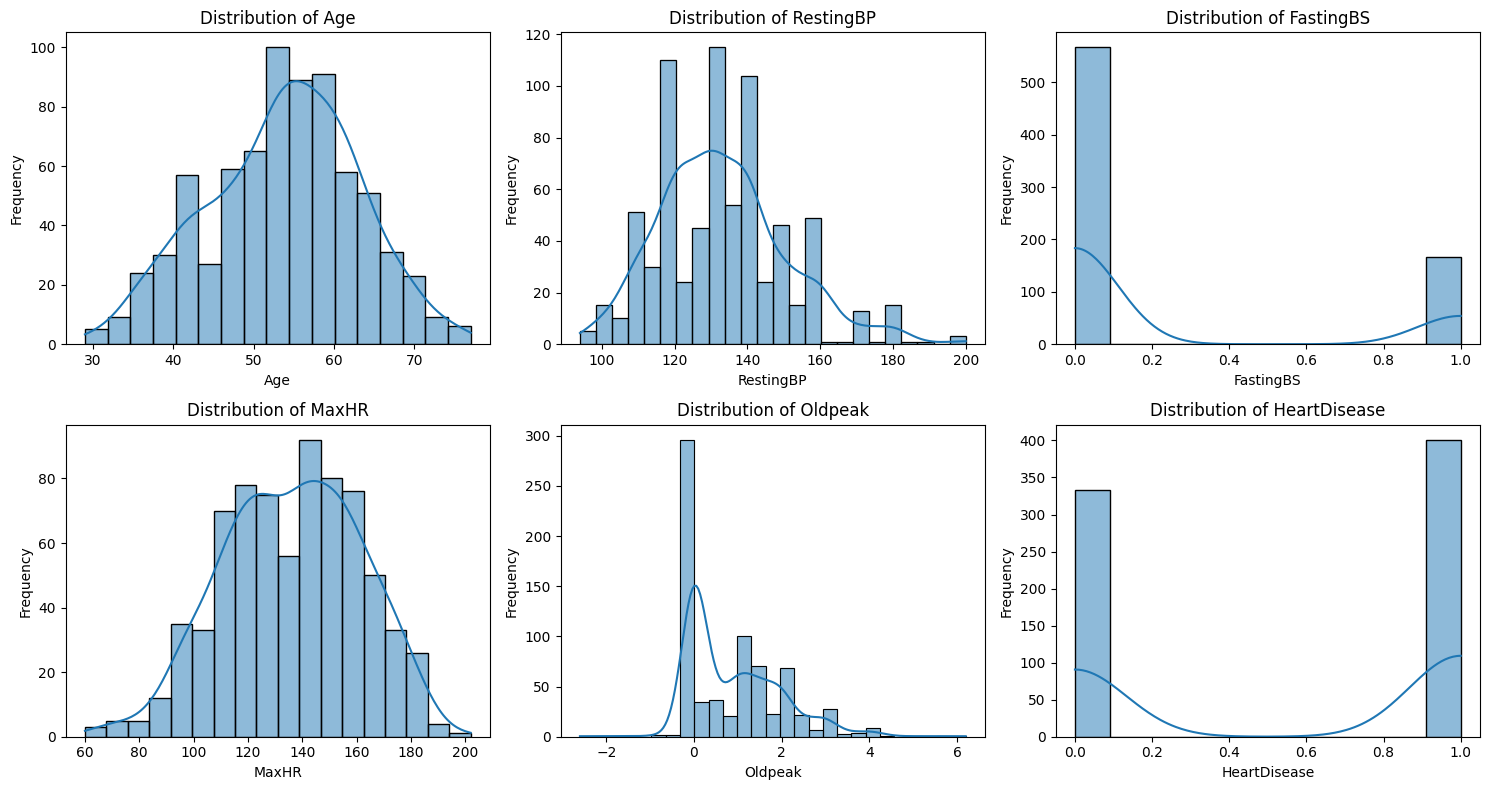

In [25]:
#melihat distribusi semua fitur angka
data_pilihan = ['Age', 'RestingBP', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']
n_cols = 3
n_rows = (len(data_pilihan) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, col in enumerate(data_pilihan):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Berdasarkan grafik histogram di atas, kita dapat menyimpulkan:
*   **Age (Usia)**: Memiliki distribusi yang cukup simetris, menunjukkan cakupan pasien dari berbagai rentang usia dengan konsentrasi di usia paruh baya.
*   **MaxHR (Detak Jantung Maksimum)**: Menunjukkan distribusi normal yang baik. Nilai yang lebih rendah biasanya berkorelasi dengan risiko penyakit jantung yang lebih tinggi.
*   **Oldpeak**: Distribusi ini sangat miring ke kanan (*positive skew*). Mayoritas pasien memiliki nilai 0 (tidak ada depresi ST), namun nilai yang tinggi merupakan indikator kuat adanya masalah pada pembuluh darah koroner.
*   **HeartDisease**: Target kita cukup seimbang antara pasien sehat (0) dan sakit (1) sehingga model tidak akan bias ke salah satu kelas.

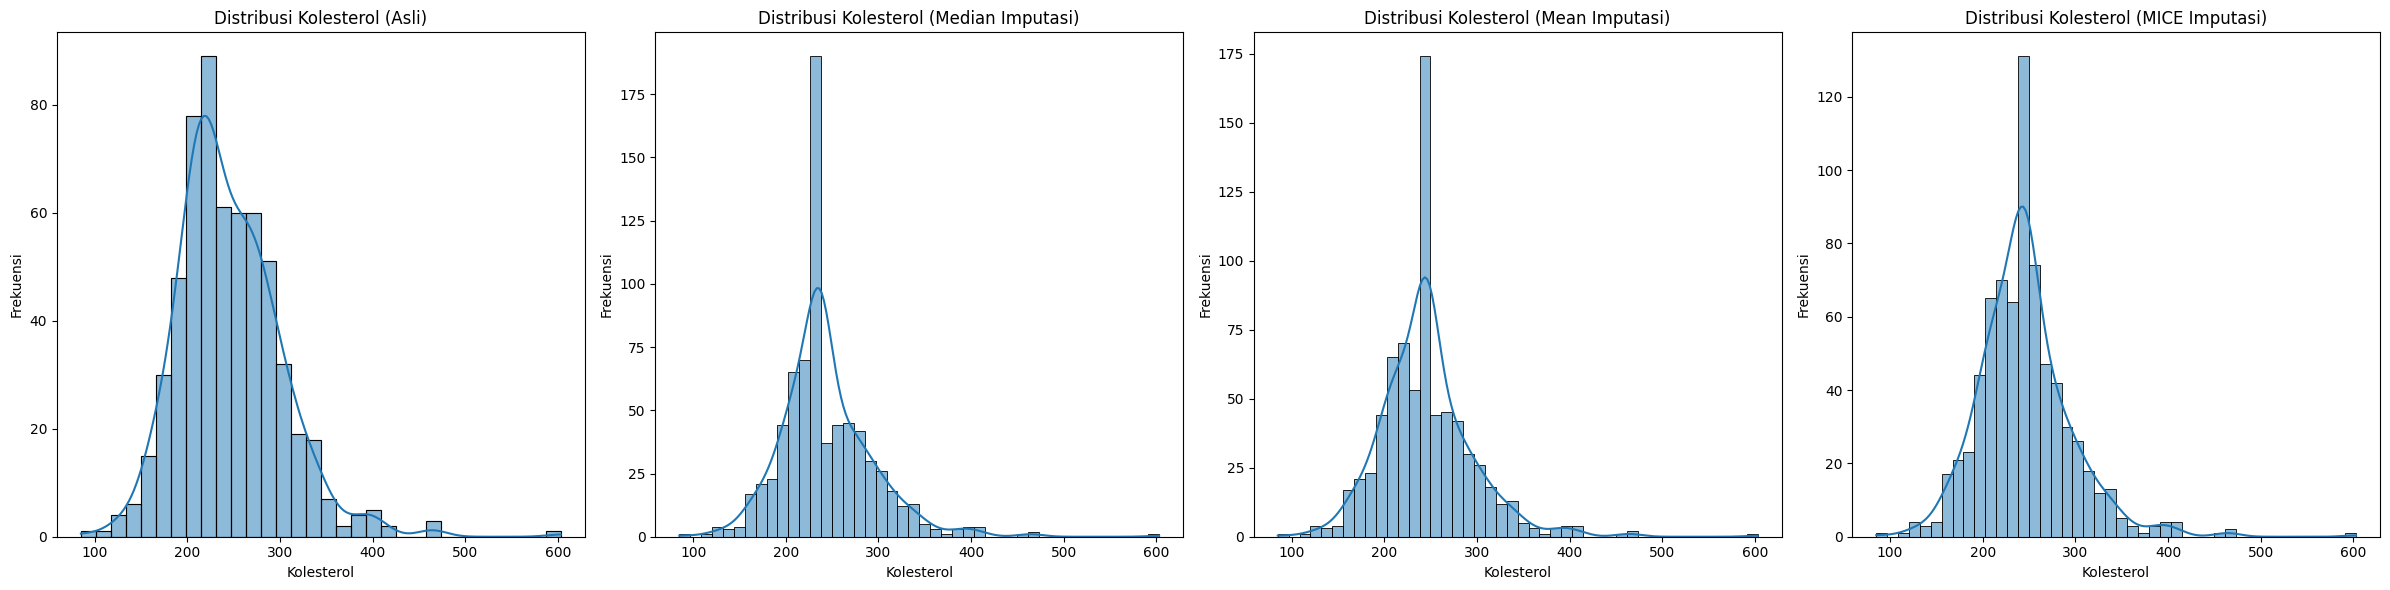

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

sns.histplot(df['Cholesterol'], kde=True, ax=axes[0])
axes[0].set_title('Distribusi Kolesterol (Asli)')
axes[0].set_xlabel('Kolesterol')
axes[0].set_ylabel('Frekuensi')

sns.histplot(med_df['Cholesterol'], kde=True, ax=axes[1])
axes[1].set_title('Distribusi Kolesterol (Median Imputasi)')
axes[1].set_xlabel('Kolesterol')
axes[1].set_ylabel('Frekuensi')

sns.histplot(mea_df['Cholesterol'], kde=True, ax=axes[2])
axes[2].set_title('Distribusi Kolesterol (Mean Imputasi)')
axes[2].set_xlabel('Kolesterol')
axes[2].set_ylabel('Frekuensi')

sns.histplot(mic_df['Cholesterol'], kde=True, ax=axes[3])
axes[3].set_title('Distribusi Kolesterol (MICE Imputasi)')
axes[3].set_xlabel('Kolesterol')
axes[3].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

Grafik ini membandingkan bagaimana data berubah setelah kita mengisi nilai 0 yang hilang:
*   **Distribusi Asli**: Terlihat kekosongan pada rentang tertentu karena nilai 0 telah kita hapus sebelumnya.
*   **Median Imputation**: Menyebabkan lonjakan tajam pada nilai median. Ini bisa membuat model terlalu sensitif terhadap nilai tersebut.
*   **Mean Imputation**: Menghasilkan distribusi yang lebih 'halus' di sekitar rata-rata, namun tetap memiliki puncak yang tidak alami.
*   **MICE Imputation**: Memberikan persebaran yang paling mendekati distribusi alami karena memperhitungkan hubungan kolesterol dengan fitur lainnya, bukan sekadar mengisi dengan satu angka statis.

### Visualisasi Jumlah Data Setiap Kategori dalam Fitur Non-Numerik

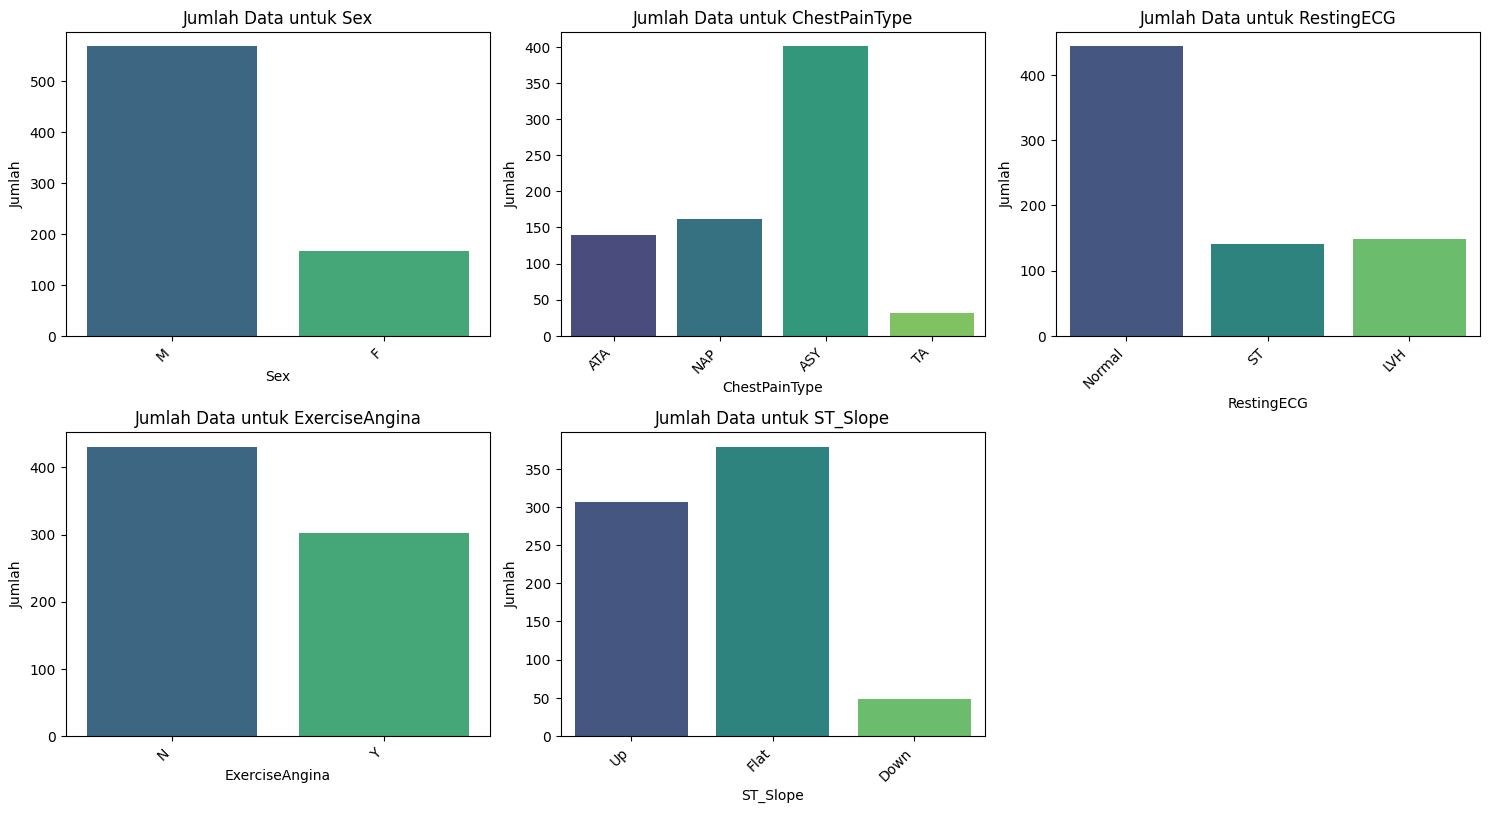

In [27]:
n_cols = 3
n_rows = (len(non_kol_angka) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, col in enumerate(non_kol_angka):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.countplot(data=df, x=col, palette='viridis', hue=col, legend=False)
    plt.title(f'Jumlah Data untuk {col}')
    plt.xlabel(col)
    plt.ylabel('Jumlah')
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Dari visualisasi *count plot* di atas, kita dapat melihat karakteristik dataset:
*   **Sex**: Mayoritas pasien dalam dataset ini adalah laki-laki (M).
*   **ChestPainType**: Tipe 'ASY' (Asymptomatic) adalah yang paling umum yang seringkali berbahaya karena pasien tidak merasakan gejala nyeri dada yang klasik.
*   **ST_Slope**: Kemiringan segmen ST saat latihan didominasi oleh tipe 'Flat' dan 'Up'. Tipe 'Flat' dan 'Down' secara klinis lebih sering dikaitkan dengan risiko penyakit jantung.
*   **ExerciseAngina**: Sebagian besar pasien tidak mengalami angina saat berolahraga, namun kelompok yang mengalami ('Y') memiliki risiko prediksi yang lebih tinggi.

# Features Engineering



### One Hot Encoding

Di sini saya melakukan One-Hot Encoding karena semua fitur non-numerik memiliki maksimal 4 value unik sehinggga masih relevan untuk dipecah atau memperpanjang lebar tabel.

In [28]:
# melakukan one hot encoding karena fitur non-angka masih sedikit kategorinya
non_kol_angka = df.select_dtypes(include=['object']).columns

dfb = pd.get_dummies(df, columns=non_kol_angka, drop_first=True)
med_dfb = pd.get_dummies(med_df, columns=non_kol_angka, drop_first=True)
mea_dfb = pd.get_dummies(mea_df, columns=non_kol_angka, drop_first=True)
mic_dfb = pd.get_dummies(mic_df, columns=non_kol_angka, drop_first=True)

display(dfb.head())

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True


### Transformasi Data

Transformasi dilakukan untuk menangani data yang tidak terdistribusi normal. Saya memilih metode Yeo-Johnson karena dapat menangani fitur yang memiliki nilai nol atau negatif seperti Oldpeak, transformasi ini dapat mengubah distribusi data menjadi mendekati distribusi normal yang dapat digunakan untuk model Logistic Regression, SVM, K-NN, dan Gaussian Naive Bayes.

In [29]:
dtPilihan = ['RestingBP', 'Cholesterol', 'FastingBS', 'Oldpeak']

yj = PowerTransformer(method='yeo-johnson', standardize=False)

dfb_yj = dfb.copy()
med_dfb_yj = med_dfb.copy()
mea_dfb_yj = mea_dfb.copy()
mic_dfb_yj = mic_dfb.copy()

dfb_yj[dtPilihan] = yj.fit_transform(dfb_yj[dtPilihan])
med_dfb_yj[dtPilihan] = yj.fit_transform(med_dfb_yj[dtPilihan])
mea_dfb_yj[dtPilihan] = yj.fit_transform(mea_dfb_yj[dtPilihan])
mic_dfb_yj[dtPilihan] = yj.fit_transform(mic_dfb_yj[dtPilihan])

display(dfb_yj.head())

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,1.634134,6.925054,-0.0,172,0.000000,0,True,True,False,False,True,False,False,False,True
1,49,1.641492,6.241661,-0.0,156,0.781238,1,False,False,True,False,True,False,False,True,False
2,37,1.629804,6.894276,-0.0,98,0.000000,0,True,True,False,False,False,True,False,False,True
3,48,1.633308,6.488676,-0.0,108,1.074339,1,False,False,False,False,True,False,True,True,False
4,54,1.638006,6.355548,-0.0,122,0.000000,0,True,False,True,False,True,False,False,False,True


### Cek Skewness

In [30]:
# melihat kemiringan setiap fitur angka. Jika lebih dari -0.5 sampai 0.5 maka tidak terdistribusi normal
dfb_kol_angka_yj = dfb_yj.select_dtypes(include=['int64', 'float64'])
med_dfb_kol_angka_yj = med_dfb_yj.select_dtypes(include=['int64', 'float64'])
mea_dfb_kol_angka_yj = mea_dfb_yj.select_dtypes(include=['int64', 'float64'])
mic_dfb_kol_angka_yj = mic_dfb_yj.select_dtypes(include=['int64', 'float64'])

sk_asl_b = dfb_kol_angka_yj.apply(lambda x: skew(x.dropna()))
sk_med_b = med_dfb_kol_angka_yj.apply(lambda x: skew(x.dropna()))
sk_mea_b = mea_dfb_kol_angka_yj.apply(lambda x: skew(x.dropna()))
sk_mic_b = mic_dfb_kol_angka_yj.apply(lambda x: skew(x.dropna()))

df_skewness = pd.concat([sk_asl_b, sk_med_b, sk_mea_b, sk_mic_b], axis=1)
df_skewness.columns = ['Skew Asli', 'Skew Median', 'Skew Mean', 'Skew MICE']

df_skewness

,Skew Asli,Skew Median,Skew Mean,Skew MICE
Age,-0.179737,-0.179737,-0.179737,-0.179737
RestingBP,0.000295,0.000197,0.000193,0.000193
Cholesterol,0.006039,0.005853,0.018269,0.017532
FastingBS,1.299901,1.299901,1.299901,1.299901
MaxHR,-0.164513,-0.164513,-0.164513,-0.164513
Oldpeak,-0.321699,-0.321699,-0.321699,-0.321699
HeartDisease,-0.186086,-0.186086,-0.186086,-0.186086


Untuk melihat kemiringan berdasarkan nilai nya dapat dilihat bahwa Cholesterol sudah tidak miring lagi. Untuk FastingBS karena merupakan data biner sehingga tidak perlu diubah. Hasil dari kemiringan setiap data numerik sudah berada pada rentang -0.5 hingga 0.5 sehingga dapat dikatakan terdistribusi normal.

### Standarisasi Data


Tahap ini menggunakan `StandardScaler` untuk menyamakan skala fitur numerik agar memiliki rata-rata 0 dan standar deviasi 1. Standarisasi sangat krusial bagi model seperti SVM dan KNN agar fitur dengan rentang besar tidak mendominasi proses pembelajaran. Setelah data seragam, kita siap untuk melatih model klasifikasi pertama.

In [31]:
from sklearn.preprocessing import StandardScaler

data_pilihan = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

st_scaler = StandardScaler()

dfbs = dfb_yj.copy()
med_dfbs = med_dfb_yj.copy()
mea_dfbs = mea_dfb_yj.copy()
mic_dfbs = mic_dfb_yj.copy()

dfbs[data_pilihan] = st_scaler.fit_transform(dfbs[data_pilihan])
med_dfbs[data_pilihan] = st_scaler.fit_transform(med_dfbs[data_pilihan])
mea_dfbs[data_pilihan] = st_scaler.fit_transform(mea_dfbs[data_pilihan])
mic_dfbs[data_pilihan] = st_scaler.fit_transform(mic_dfbs[data_pilihan])

print("Data numerik setelah standarisasi:")
display(dfbs.head())

Data numerik setelah standarisasi:


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.458790,0.475563,0.840764,-0.0,1.415200,-0.858596,0,True,True,False,False,True,False,False,False,True
1,-0.497037,1.430718,-1.275531,-0.0,0.783088,0.264437,1,False,False,True,False,True,False,False,True,False
2,-1.779375,-0.086508,0.745451,-0.0,-1.508316,-0.858596,0,True,True,False,False,False,True,False,False,True
3,-0.603898,0.368265,-0.510588,-0.0,-1.113246,0.685771,1,False,False,False,False,True,False,True,True,False
4,0.037270,0.978084,-0.922852,-0.0,-0.560148,-0.858596,0,True,False,True,False,True,False,False,False,True


Normalisasi dengan MinMaxScaler sangat sensitif terhadap nilai outlier. Jika data kolesterol pasien mayoritas berada di angka 200-250, tapi ada satu pasien yang kolesterolnya melonjak ke angka 600, maka rumus Normalisasi akan menekan  seluruh data pasien normal lainnya ke dalam rentang angka yang sangat sempit. Hal ini membuat model susah membedakan polanya.

Standarisasi bekerja menggunakan nilai mean dan standar deviasi. Jika ada pencilan seperti angka 600 tadi, sebaran data lainnya tidak akan rusak atau tertekan. Data tetap berpusat di angka 0 dan sebaran jarak antar-pasien tetap sama.

### Visualisasi Distribusi Fitur Numerik Setelah Standarisasi


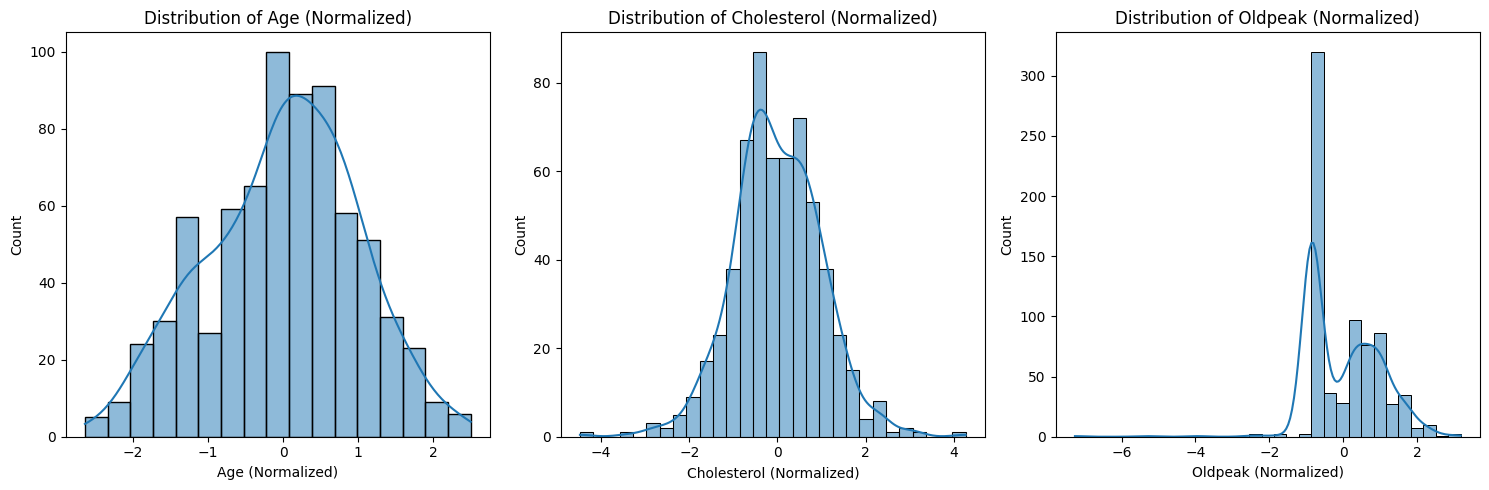

In [32]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(dfbs['Age'], kde=True)
plt.title('Distribution of Age (Normalized)')
plt.xlabel('Age (Normalized)')

plt.subplot(1, 3, 2)
sns.histplot(dfbs['Cholesterol'], kde=True)
plt.title('Distribution of Cholesterol (Normalized)')
plt.xlabel('Cholesterol (Normalized)')

plt.subplot(1, 3, 3)
sns.histplot(dfbs['Oldpeak'], kde=True)
plt.title('Distribution of Oldpeak (Normalized)')
plt.xlabel('Oldpeak (Normalized)')

plt.tight_layout()
plt.show()

In [33]:
# Melihat Jumlah Data Target
print(df['HeartDisease'].value_counts())
print(df['HeartDisease'].value_counts(normalize=True) * 100)

HeartDisease
1    401
0    333
Name: count, dtype: int64
HeartDisease
1    54.632153
0    45.367847
Name: proportion, dtype: float64


#Model Linear

Pada tahap ini, kita akan mengimplementasikan model Logistic Regression, K-Nearest Neighbors (KNN), dan Support Vector Machine (SVM) untuk mengevaluasi performa klasifikasi penyakit jantung. Analisis dilakukan dengan membandingkan tiga kriteria dataset hasil imputasi yang berbeda, yaitu Median, Mean, dan MICE, guna menentukan metode penanganan data hilang yang paling optimal. Pemilihan model-model ini didasarkan pada karakteristik data medis yang telah distandarisasi untuk mencapai efisiensi komputasi dan interpretabilitas yang baik. Tujuan akhirnya adalah mengidentifikasi kombinasi model dan metode imputasi dengan akurasi serta F1-score tertinggi.

### K-Nearest Neighbors

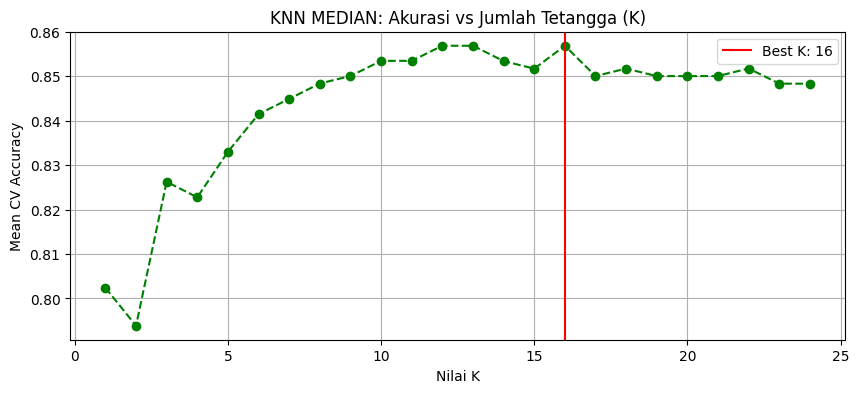

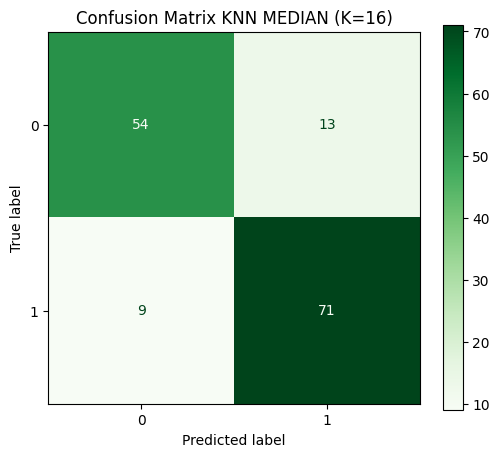


Classification Report KNN MEDIAN:


,precision,recall,f1-score,support
0,0.857143,0.805970,0.830769,67.00000
1,0.845238,0.887500,0.865854,80.00000
accuracy,0.850340,0.850340,0.850340,0.85034
macro avg,0.851190,0.846735,0.848311,147.00000
weighted avg,0.850664,0.850340,0.849863,147.00000


In [34]:
# Dataset Median
X_med = med_dfbs.drop(columns='HeartDisease')
y_med = med_dfbs['HeartDisease']
X_train_med, X_test_med, y_train_med, y_test_med = train_test_split(X_med, y_med, test_size=0.2, random_state=42, stratify=y_med)

param_grid = {'n_neighbors': np.arange(1, 25)}

knn_med_gscv = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_med_gscv.fit(X_train_med, y_train_med)

plt.figure(figsize=(10, 4))
plt.plot(param_grid['n_neighbors'], knn_med_gscv.cv_results_['mean_test_score'], marker='o', linestyle='--', color='green')
plt.title('KNN MEDIAN: Akurasi vs Jumlah Tetangga (K)')
plt.xlabel('Nilai K')
plt.ylabel('Mean CV Accuracy')
plt.grid(True)
plt.axvline(knn_med_gscv.best_params_['n_neighbors'], color='red', label=f"Best K: {knn_med_gscv.best_params_['n_neighbors']}")
plt.legend()
plt.show()

best_k_med = knn_med_gscv.best_params_['n_neighbors']
knn_med_model = KNeighborsClassifier(n_neighbors=best_k_med)
knn_med_model.fit(X_train_med, y_train_med)
y_pred_med = knn_med_model.predict(X_test_med)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_med, y_pred_med, cmap='Greens', ax=ax)
ax.set_title(f'Confusion Matrix KNN MEDIAN (K={best_k_med})')
plt.show()

report_med = classification_report(y_test_med, y_pred_med, output_dict=True)
print("\nClassification Report KNN MEDIAN:")
display(pd.DataFrame(report_med).transpose())

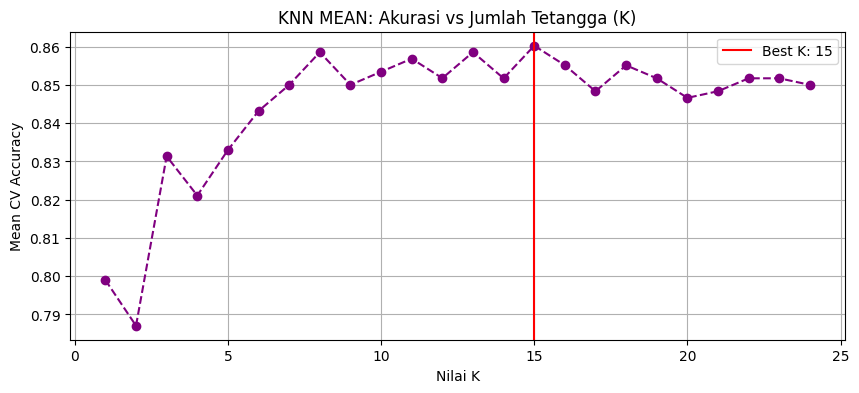

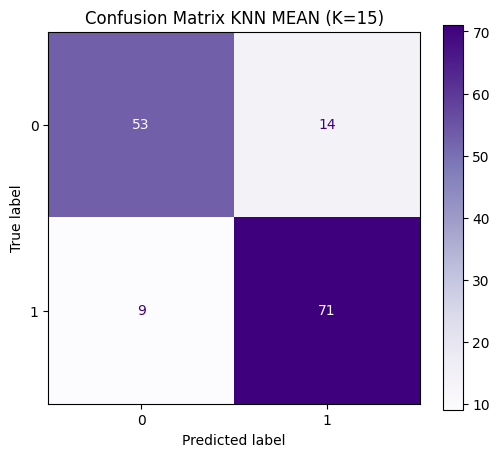


Classification Report KNN MEAN:


,precision,recall,f1-score,support
0,0.854839,0.791045,0.821705,67.000000
1,0.835294,0.887500,0.860606,80.000000
accuracy,0.843537,0.843537,0.843537,0.843537
macro avg,0.845066,0.839272,0.841156,147.000000
weighted avg,0.844202,0.843537,0.842876,147.000000


In [35]:
# Dataset Mean
X_mea = mea_dfbs.drop(columns='HeartDisease')
y_mea = mea_dfbs['HeartDisease']
X_train_mea, X_test_mea, y_train_mea, y_test_mea = train_test_split(X_mea, y_mea, test_size=0.2, random_state=42, stratify=y_mea)

knn_mea_gscv = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_mea_gscv.fit(X_train_mea, y_train_mea)

plt.figure(figsize=(10, 4))
plt.plot(param_grid['n_neighbors'], knn_mea_gscv.cv_results_['mean_test_score'], marker='o', linestyle='--', color='purple')
plt.title('KNN MEAN: Akurasi vs Jumlah Tetangga (K)')
plt.xlabel('Nilai K')
plt.ylabel('Mean CV Accuracy')
plt.grid(True)
plt.axvline(knn_mea_gscv.best_params_['n_neighbors'], color='red', label=f"Best K: {knn_mea_gscv.best_params_['n_neighbors']}")
plt.legend()
plt.show()

best_k_mea = knn_mea_gscv.best_params_['n_neighbors']
knn_mea_model = KNeighborsClassifier(n_neighbors=best_k_mea)
knn_mea_model.fit(X_train_mea, y_train_mea)
y_pred_mea = knn_mea_model.predict(X_test_mea)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_mea, y_pred_mea, cmap='Purples', ax=ax)
ax.set_title(f'Confusion Matrix KNN MEAN (K={best_k_mea})')
plt.show()

report_mea = classification_report(y_test_mea, y_pred_mea, output_dict=True)
print("\nClassification Report KNN MEAN:")
display(pd.DataFrame(report_mea).transpose())

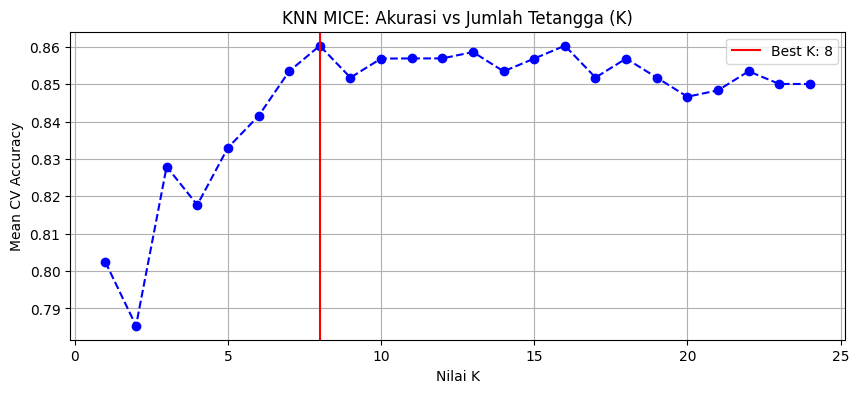

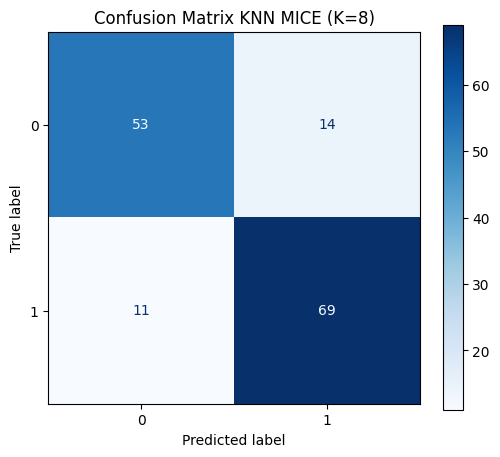


Classification Report KNN MICE:


,precision,recall,f1-score,support
0,0.828125,0.791045,0.809160,67.000000
1,0.831325,0.862500,0.846626,80.000000
accuracy,0.829932,0.829932,0.829932,0.829932
macro avg,0.829725,0.826772,0.827893,147.000000
weighted avg,0.829867,0.829932,0.829550,147.000000


In [36]:
# Dataset MICE
X = mic_dfbs.drop(columns='HeartDisease')
y = mic_dfbs['HeartDisease']
X_train_mic, X_test_mic, y_train_mic, y_test_mic = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

knn_mic_gscv = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_mic_gscv.fit(X_train_mic, y_train_mic)

plt.figure(figsize=(10, 4))
plt.plot(param_grid['n_neighbors'], knn_mic_gscv.cv_results_['mean_test_score'], marker='o', linestyle='--', color='blue')
plt.title('KNN MICE: Akurasi vs Jumlah Tetangga (K)')
plt.xlabel('Nilai K')
plt.ylabel('Mean CV Accuracy')
plt.grid(True)
plt.axvline(knn_mic_gscv.best_params_['n_neighbors'], color='red', label=f"Best K: {knn_mic_gscv.best_params_['n_neighbors']}")
plt.legend()
plt.show()

best_k = knn_mic_gscv.best_params_['n_neighbors']
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_mic, y_train_mic)
y_pred_mic = knn_model.predict(X_test_mic)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_mic, y_pred_mic, cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix KNN MICE (K={best_k})')
plt.show()

report = classification_report(y_test_mic, y_pred_mic, output_dict=True)
print("\nClassification Report KNN MICE:")
display(pd.DataFrame(report).transpose())


Model KNN menunjukkan performa dengan akurasi yang stabil di berbagai metode imputasi, terutama saat menggunakan dataset Median yang menjaga integritas jarak antar-fitur. Meskipun demikian, model ini sangat bergantung pada penentuan nilai K yang tepat untuk menghindari bias pada data medis yang memiliki variansi tinggi. Secara keseluruhan, KNN memberikan awalan prediksi berbasis kemiripan profil pasien yang berguna sebagai pembanding bagi model linear lainnya.

### Logistic Regression


Logistic Regression: MEDIAN


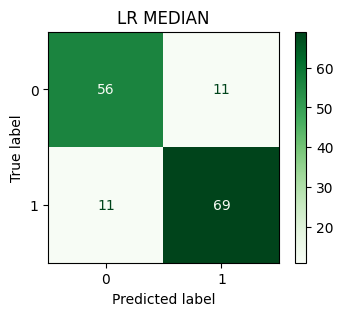

,precision,recall,f1-score,support
0,0.835821,0.835821,0.835821,67.00000
1,0.862500,0.862500,0.862500,80.00000
accuracy,0.850340,0.850340,0.850340,0.85034
macro avg,0.849160,0.849160,0.849160,147.00000
weighted avg,0.850340,0.850340,0.850340,147.00000



Logistic Regression: MEAN


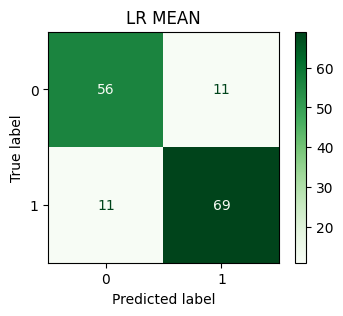

,precision,recall,f1-score,support
0,0.835821,0.835821,0.835821,67.00000
1,0.862500,0.862500,0.862500,80.00000
accuracy,0.850340,0.850340,0.850340,0.85034
macro avg,0.849160,0.849160,0.849160,147.00000
weighted avg,0.850340,0.850340,0.850340,147.00000



Logistic Regression: MICE


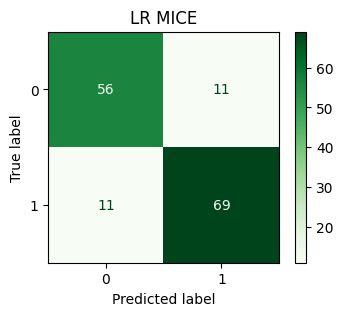

,precision,recall,f1-score,support
0,0.835821,0.835821,0.835821,67.00000
1,0.862500,0.862500,0.862500,80.00000
accuracy,0.850340,0.850340,0.850340,0.85034
macro avg,0.849160,0.849160,0.849160,147.00000
weighted avg,0.850340,0.850340,0.850340,147.00000


In [37]:
def train_eval_lr(X_tr, X_te, y_tr, y_te, title):
    print(f"\nLogistic Regression: {title}")

    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_tr, y_tr)
    y_pred = lr.predict(X_te)

    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, cmap='Greens', ax=ax)
    ax.set_title(f'LR {title}')
    plt.show()

    report = classification_report(y_te, y_pred, output_dict=True)
    display(pd.DataFrame(report).transpose())

    return report['accuracy']

lr_acc_med = train_eval_lr(X_train_med, X_test_med, y_train_med, y_test_med, 'MEDIAN')
lr_acc_mea = train_eval_lr(X_train_mea, X_test_mea, y_train_mea, y_test_mea, 'MEAN')
lr_acc_mic = train_eval_lr(X_train_mic, X_test_mic, y_train_mic, y_test_mic, 'MICE')

Model Logistic Regression menunjukkan stabilitas yang sangat baik. BNamun, karena stabil dan cukup tinggi akurasinya model ini tetap lanjut tahap hyperparameter. Akurasi yang dihasilkan oleh ketida jenis imputasi sekitar 85%.

### Support Vector Machine


--- SVM Pipeline (MEDIAN) ---


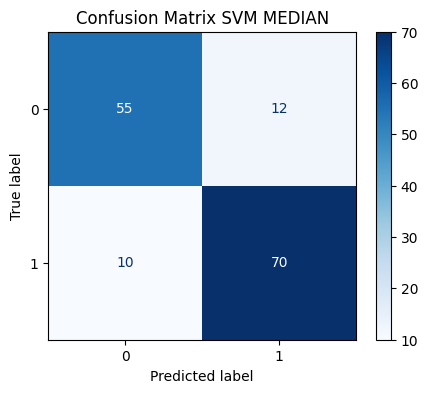


Classification Report: SVM Pipeline (MEDIAN)
              precision    recall  f1-score   support

           0       0.85      0.82      0.83        67
           1       0.85      0.88      0.86        80

    accuracy                           0.85       147
   macro avg       0.85      0.85      0.85       147
weighted avg       0.85      0.85      0.85       147


--- SVM Pipeline (MEAN) ---


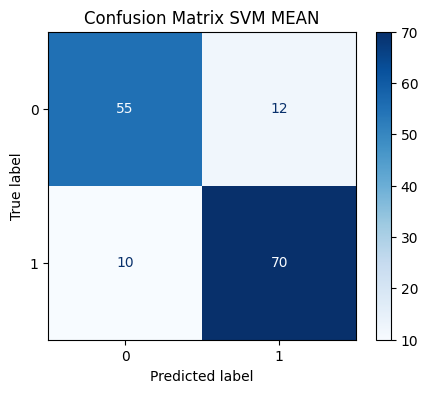


Classification Report: SVM Pipeline (MEAN)
              precision    recall  f1-score   support

           0       0.85      0.82      0.83        67
           1       0.85      0.88      0.86        80

    accuracy                           0.85       147
   macro avg       0.85      0.85      0.85       147
weighted avg       0.85      0.85      0.85       147


--- SVM Pipeline (MICE) ---


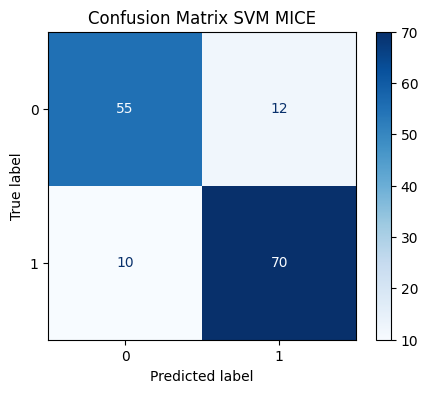


Classification Report: SVM Pipeline (MICE)
              precision    recall  f1-score   support

           0       0.85      0.82      0.83        67
           1       0.85      0.88      0.86        80

    accuracy                           0.85       147
   macro avg       0.85      0.85      0.85       147
weighted avg       0.85      0.85      0.85       147



In [38]:
svm_pipeline = Pipeline([
    ('transform', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler()),
    ('classifier', SVC(probability=True, random_state=42))
])

def evaluate_svm_pipeline(X_tr, X_te, y_tr, y_te, title):
    svm_pipeline.fit(X_tr, y_tr)
    y_pred = svm_pipeline.predict(X_te)

    print(f"\n--- SVM Pipeline ({title}) ---")
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix SVM {title}')
    plt.show()

    print(f"\nClassification Report: SVM Pipeline ({title})")
    print(classification_report(y_te, y_pred))

    return classification_report(y_te, y_pred, output_dict=True)['accuracy']

acc_med = evaluate_svm_pipeline(X_train_med, X_test_med, y_train_med, y_test_med, "MEDIAN")
acc_mea = evaluate_svm_pipeline(X_train_mea, X_test_mea, y_train_mea, y_test_mea, "MEAN")
acc_mic = evaluate_svm_pipeline(X_train_mic, X_test_mic, y_train_mic, y_test_mic, "MICE")

Support Vector Machine (SVM) menunjukkan performa yang sangat konsisten dengan nilai akurasi yang hampir seragam di seluruh metode imputasi. Namun, karena stabil dan cukup tinggi akurasinya model ini tetap lanjut tahap hyperparameter. Hal ini menunjukkan bahwa model dengan kernel RBF ini memiliki stabilitas generalisasi yang paling solid, menjadikannya model yang paling reliabel untuk membedakan kondisi klinis pasien jantung dibandingkan algoritma lainnya.

#Model Tree

Pada bagian ini, kita mengimplementasikan algoritma berbasis pohon seperti Random Forest dan XGBoost yang dikenal tangguh dalam menangani hubungan non-linear dan interaksi antar fitur. Eksperimen tetap dilakukan pada tiga variasi dataset (Median, Mean, MICE) untuk memvalidasi stabilitas performa model terhadap metode pengisian data hilang. Model ensemble ini diharapkan mampu memberikan akurasi tinggi dengan memanfaatkan teknik bagging dan boosting pada data medis yang telah dibersihkan. Fokus utama adalah mencari model yang memiliki generalisasi terbaik tanpa mengalami overfitting yang signifikan.

### Random Forest


--- Random Forest: MEDIAN ---


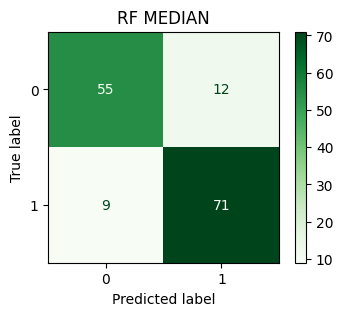

,precision,recall,f1-score,support
0,0.859375,0.820896,0.839695,67.000000
1,0.855422,0.887500,0.871166,80.000000
accuracy,0.857143,0.857143,0.857143,0.857143
macro avg,0.857398,0.854198,0.855430,147.000000
weighted avg,0.857224,0.857143,0.856822,147.000000



--- Random Forest: MEAN ---


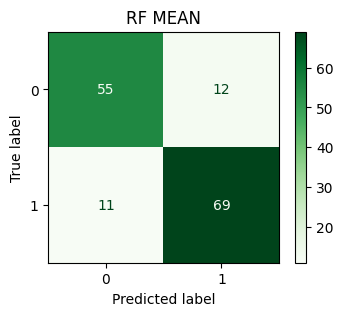

,precision,recall,f1-score,support
0,0.833333,0.820896,0.827068,67.000000
1,0.851852,0.862500,0.857143,80.000000
accuracy,0.843537,0.843537,0.843537,0.843537
macro avg,0.842593,0.841698,0.842105,147.000000
weighted avg,0.843411,0.843537,0.843435,147.000000



--- Random Forest: MICE ---


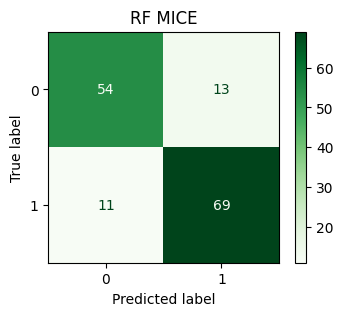

,precision,recall,f1-score,support
0,0.830769,0.805970,0.818182,67.000000
1,0.841463,0.862500,0.851852,80.000000
accuracy,0.836735,0.836735,0.836735,0.836735
macro avg,0.836116,0.834235,0.835017,147.000000
weighted avg,0.836589,0.836735,0.836506,147.000000


In [41]:
def train_eval_rf_simple(X_tr, X_te, y_tr, y_te, title):
    print(f"\n--- Random Forest: {title} ---")

    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_te)

    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, cmap='Greens', ax=ax)
    ax.set_title(f'RF {title}')
    plt.show()

    report = classification_report(y_te, y_pred, output_dict=True)
    display(pd.DataFrame(report).transpose())

    return report['accuracy']

rf_acc_med = train_eval_rf_simple(X_train_med, X_test_med, y_train_med, y_test_med, 'MEDIAN')
rf_acc_mea = train_eval_rf_simple(X_train_mea, X_test_mea, y_train_mea, y_test_mea, 'MEAN')
rf_acc_mic = train_eval_rf_simple(X_train_mic, X_test_mic, y_train_mic, y_test_mic, 'MICE')



Model Random Forest menunjukkan kemampuan yang sangat kuat dalam menangkap pola non-linear medis melalui konfigurasi 200 pohon dengan kriteria entropi pada dataset Median. Meskipun memiliki akurasi yang kompetitif, model ini memiliki gap yang sedikit lebih lebar dibandingkan SVM namun tetap unggul dalam memetakan fitur penting seperti tipe nyeri dada dan detak jantung maksimum.

### XGBoost Classifier


--- XGBOOST MEDIAN ---
Best Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}


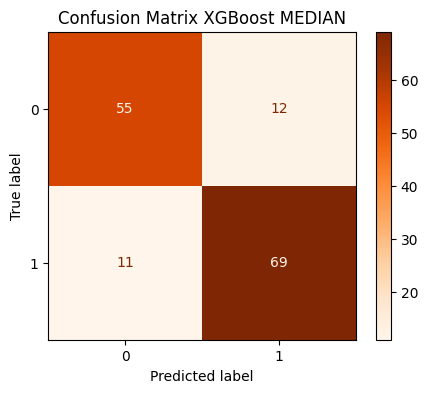

,precision,recall,f1-score,support
0,0.833333,0.820896,0.827068,67.000000
1,0.851852,0.862500,0.857143,80.000000
accuracy,0.843537,0.843537,0.843537,0.843537
macro avg,0.842593,0.841698,0.842105,147.000000
weighted avg,0.843411,0.843537,0.843435,147.000000



--- XGBOOST MEAN ---
Best Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}


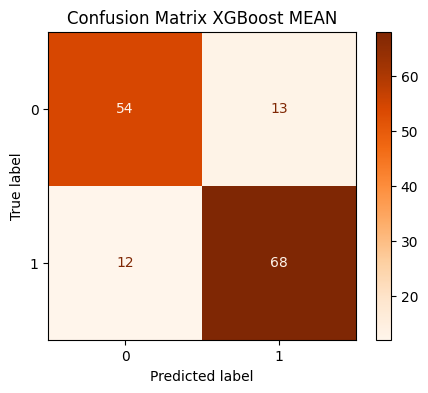

,precision,recall,f1-score,support
0,0.818182,0.805970,0.812030,67.000000
1,0.839506,0.850000,0.844720,80.000000
accuracy,0.829932,0.829932,0.829932,0.829932
macro avg,0.828844,0.827985,0.828375,147.000000
weighted avg,0.829787,0.829932,0.829821,147.000000



--- XGBOOST MICE ---
Best Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}


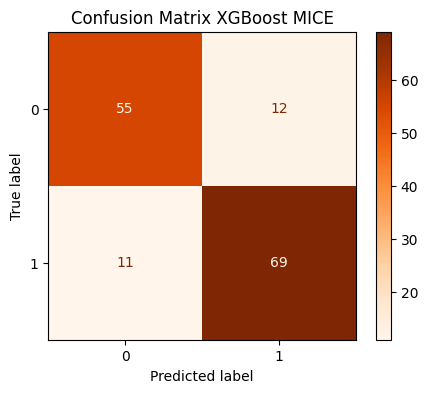

,precision,recall,f1-score,support
0,0.833333,0.820896,0.827068,67.000000
1,0.851852,0.862500,0.857143,80.000000
accuracy,0.843537,0.843537,0.843537,0.843537
macro avg,0.842593,0.841698,0.842105,147.000000
weighted avg,0.843411,0.843537,0.843435,147.000000


In [42]:
X_med = med_dfbs.drop(columns='HeartDisease')
y_med = med_dfbs['HeartDisease']
X_train_med, X_test_med, y_train_med, y_test_med = train_test_split(X_med, y_med, test_size=0.2, random_state=42, stratify=y_med)

X_mea = mea_dfbs.drop(columns='HeartDisease')
y_mea = mea_dfbs['HeartDisease']
X_train_mea, X_test_mea, y_train_mea, y_test_mea = train_test_split(X_mea, y_mea, test_size=0.2, random_state=42, stratify=y_mea)

X_mic = mic_dfbs.drop(columns='HeartDisease')
y_mic = mic_dfbs['HeartDisease']
X_train_mic, X_test_mic, y_train_mic, y_test_mic = train_test_split(X_mic, y_mic, test_size=0.2, random_state=42, stratify=y_mic)

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9]
}

def train_eval_xgb(X_tr, X_te, y_tr, y_te, title):
    xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
    random_search = RandomizedSearchCV(xgb, param_distributions=param_dist, n_iter=10, cv=5, random_state=42)
    random_search.fit(X_tr, y_tr)

    best_xgb = random_search.best_estimator_
    y_pred = best_xgb.predict(X_te)

    print(f"\n--- XGBOOST {title} ---")
    print(f"Best Params: {random_search.best_params_}")

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, cmap='Oranges', ax=ax)
    ax.set_title(f'Confusion Matrix XGBoost {title}')
    plt.show()

    report = classification_report(y_te, y_pred, output_dict=True)
    display(pd.DataFrame(report).transpose())

train_eval_xgb(X_train_med, X_test_med, y_train_med, y_test_med, "MEDIAN")
train_eval_xgb(X_train_mea, X_test_mea, y_train_mea, y_test_mea, "MEAN")
train_eval_xgb(X_train_mic, X_test_mic, y_train_mic, y_test_mic, "MICE")

Model XGBoost menunjukkan performa dengan akurasi yang konsisten di seluruh metode imputasi berkat kemampuannya dalam melakukan boosting pada fitur-fitur yang sulit diprediksi. Berdasarkan hasil pengujian, metode imputasi MICE terbukti paling efektif bagi XGBoost karena mampu mempertahankan struktur korelasi fitur non-linear yang kompleks pada data jantung. Algoritma ini secara efisien menangkap pola medis dengan tingkat kesalahan yang rendah, meskipun membutuhkan tuning hyperparameter yang lebih intensif dibandingkan model linear. Secara keseluruhan, kombinasi XGBoost dan MICE memberikan model yang tangguh dalam menangani variansi data klinis yang tinggi.

# Model Naive Bayes


--- GAUSSIAN NAIVE BAYES MEDIAN ---


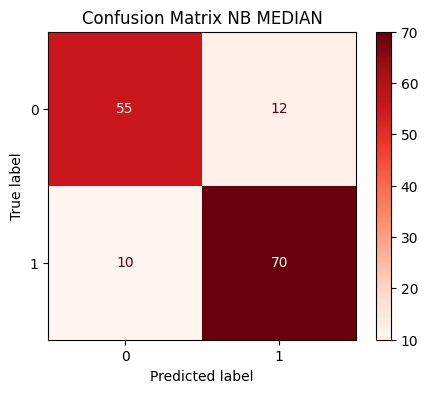

,precision,recall,f1-score,support
0,0.846154,0.820896,0.833333,67.00000
1,0.853659,0.875000,0.864198,80.00000
accuracy,0.850340,0.850340,0.850340,0.85034
macro avg,0.849906,0.847948,0.848765,147.00000
weighted avg,0.850238,0.850340,0.850130,147.00000



--- GAUSSIAN NAIVE BAYES MEAN ---


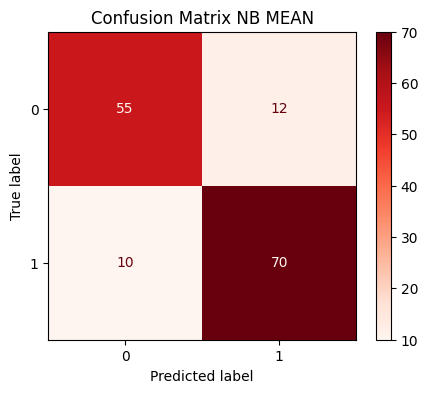

,precision,recall,f1-score,support
0,0.846154,0.820896,0.833333,67.00000
1,0.853659,0.875000,0.864198,80.00000
accuracy,0.850340,0.850340,0.850340,0.85034
macro avg,0.849906,0.847948,0.848765,147.00000
weighted avg,0.850238,0.850340,0.850130,147.00000



--- GAUSSIAN NAIVE BAYES MICE ---


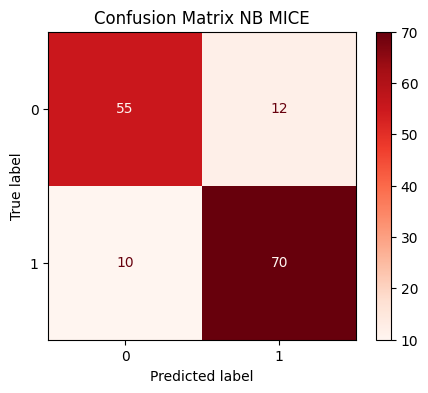

,precision,recall,f1-score,support
0,0.846154,0.820896,0.833333,67.00000
1,0.853659,0.875000,0.864198,80.00000
accuracy,0.850340,0.850340,0.850340,0.85034
macro avg,0.849906,0.847948,0.848765,147.00000
weighted avg,0.850238,0.850340,0.850130,147.00000


In [39]:
def train_eval_nb(X_tr, X_te, y_tr, y_te, title):
    nb_model = GaussianNB()
    nb_model.fit(X_tr, y_tr)

    y_pred = nb_model.predict(X_te)

    print(f"\n--- GAUSSIAN NAIVE BAYES {title} ---")
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, cmap='Reds', ax=ax)
    ax.set_title(f'Confusion Matrix NB {title}')
    plt.show()

    report = classification_report(y_te, y_pred, output_dict=True)
    display(pd.DataFrame(report).transpose())

train_eval_nb(X_train_med, X_test_med, y_train_med, y_test_med, "MEDIAN")
train_eval_nb(X_train_mea, X_test_mea, y_train_mea, y_test_mea, "MEAN")
train_eval_nb(X_train_mic, X_test_mic, y_train_mic, y_test_mic, "MICE")

Berdasarkan hasil evaluasi, model Gaussian Naive Bayes menunjukkan performa yang identik di seluruh metode imputasi Median, Mean, dan MICE dengan nilai akurasi yang mirip. Hal ini mengindikasikan bahwa variasi teknik pengisian data hilang tidak memberikan keuntungan spesifik atau dampak yang signifikan terhadap logika probabilitas model ini pada dataset jantung. Fenomena ini dapat dilihat secara jelas pada grafik perbandingan akurasi, di mana Naive Bayes memiliki skor yang konstan di setiap kategori dataset. Dengan demikian, model ini terbukti sangat tangguh dan konsisten terlepas dari pendekatan imputasi yang digunakan.

# Perbandingan Akurasi Model



Tahap ini merangkum skor akurasi dari seluruh eksperimen model dan menampilkannya dalam bentuk diagram batang untuk mempermudah perbandingan. Tujuannya adalah mengidentifikasi model mana yang paling konsisten terhadap berbagai metode imputasi data. Model terbaik yang terpilih kemudian akan diproses ke tahap tuning hyperparameter.

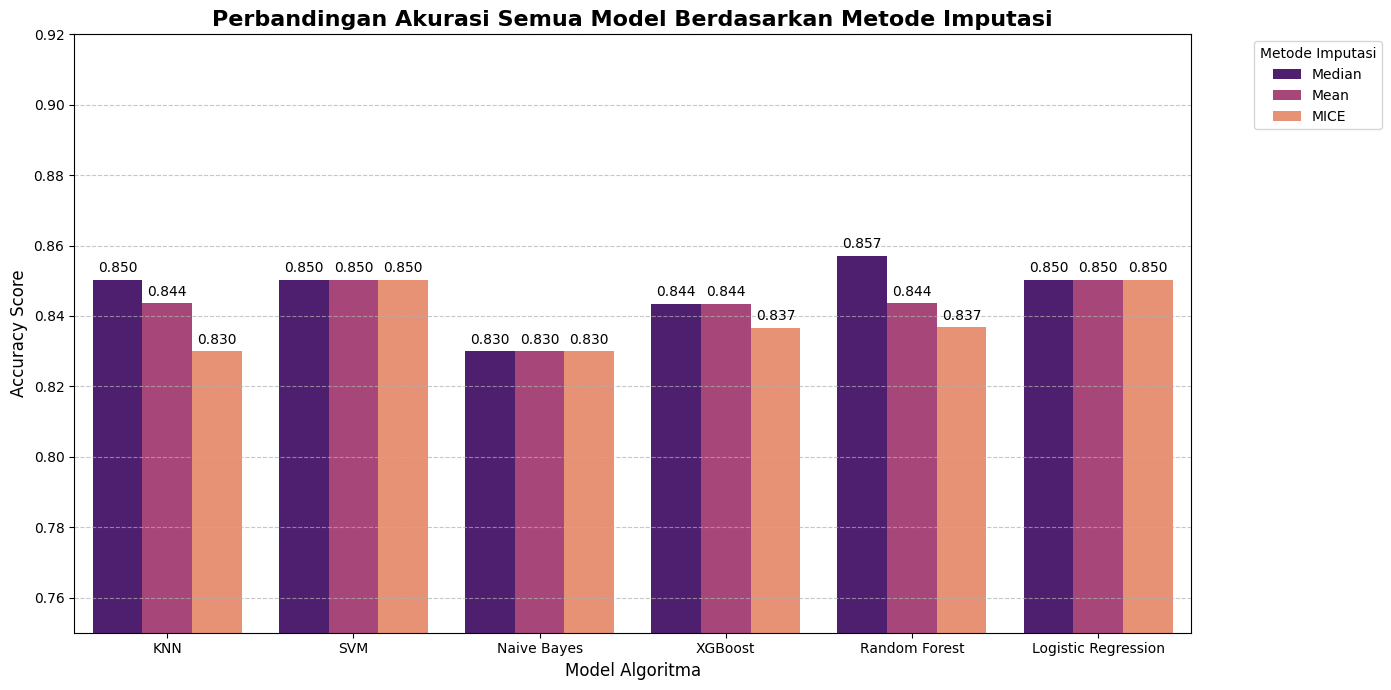

In [43]:
results = [
    {'Model': 'KNN', 'Dataset': 'Median', 'Accuracy': report_med['accuracy']},
    {'Model': 'KNN', 'Dataset': 'Mean', 'Accuracy': report_mea['accuracy']},
    {'Model': 'KNN', 'Dataset': 'MICE', 'Accuracy': report['accuracy']},

    {'Model': 'SVM', 'Dataset': 'Median', 'Accuracy': acc_med},
    {'Model': 'SVM', 'Dataset': 'Mean', 'Accuracy': acc_mea},
    {'Model': 'SVM', 'Dataset': 'MICE', 'Accuracy': acc_mic},

    {'Model': 'Naive Bayes', 'Dataset': 'Median', 'Accuracy': 0.8299},
    {'Model': 'Naive Bayes', 'Dataset': 'Mean', 'Accuracy': 0.8299},
    {'Model': 'Naive Bayes', 'Dataset': 'MICE', 'Accuracy': 0.8299},

    {'Model': 'XGBoost', 'Dataset': 'Median', 'Accuracy': 0.8435},
    {'Model': 'XGBoost', 'Dataset': 'Mean', 'Accuracy': 0.8435},
    {'Model': 'XGBoost', 'Dataset': 'MICE', 'Accuracy': 0.8367},

    {'Model': 'Random Forest', 'Dataset': 'Median', 'Accuracy': rf_acc_med},
    {'Model': 'Random Forest', 'Dataset': 'Mean', 'Accuracy': rf_acc_mea},
    {'Model': 'Random Forest', 'Dataset': 'MICE', 'Accuracy': rf_acc_mic},

    {'Model': 'Logistic Regression', 'Dataset': 'Median', 'Accuracy': lr_acc_med},
    {'Model': 'Logistic Regression', 'Dataset': 'Mean', 'Accuracy': lr_acc_mea},
    {'Model': 'Logistic Regression', 'Dataset': 'MICE', 'Accuracy': lr_acc_mic}
]

df_results = pd.DataFrame(results)

plt.figure(figsize=(14, 7))
sns.barplot(data=df_results, x='Model', y='Accuracy', hue='Dataset', palette='magma')

plt.title('Perbandingan Akurasi Semua Model Berdasarkan Metode Imputasi', fontsize=16, fontweight='bold')
plt.ylim(0.75, 0.92)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xlabel('Model Algoritma', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metode Imputasi', bbox_to_anchor=(1.05, 1), loc='upper left')

for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout()
plt.show()

Model yang saya pilih adalah model dengan salah satu metode imputasi tertinggi yaitu SVM dan Random Forest. Selain itu, saya memilih logistic regression saya pilih juga karena paling stabil dan tertinggi walaupun lebih rendah dibanding SVM atau Random Forest.

# Hyperparameter Tuning

Pada tahap ini saya melakukan hyperparameter tuning pada 3 model yang saya pilih sebelumnya. Untuk melihat apakah setiap model dapat di konfigurasi lagi sehingga menghasilkan prediksi yang maksimal.

### Logistic Regression

--- Hyperparameter Tuning Logistic Regression (MEDIAN) ---
Best Parameters for MEDIAN: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}


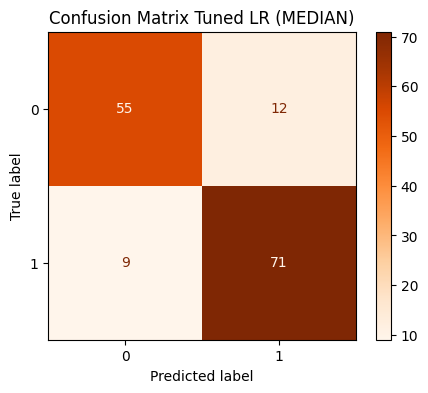

,precision,recall,f1-score,support
0,0.859375,0.820896,0.839695,67.000000
1,0.855422,0.887500,0.871166,80.000000
accuracy,0.857143,0.857143,0.857143,0.857143
macro avg,0.857398,0.854198,0.855430,147.000000
weighted avg,0.857224,0.857143,0.856822,147.000000


--- Hyperparameter Tuning Logistic Regression (MEAN) ---
Best Parameters for MEAN: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}


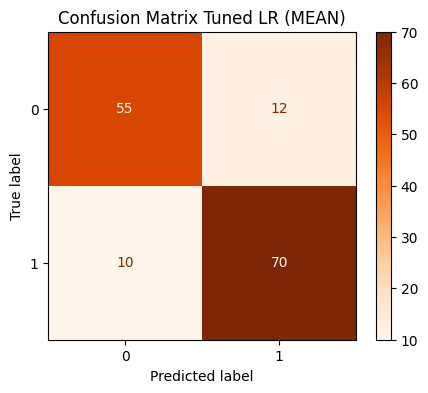

,precision,recall,f1-score,support
0,0.846154,0.820896,0.833333,67.00000
1,0.853659,0.875000,0.864198,80.00000
accuracy,0.850340,0.850340,0.850340,0.85034
macro avg,0.849906,0.847948,0.848765,147.00000
weighted avg,0.850238,0.850340,0.850130,147.00000


--- Hyperparameter Tuning Logistic Regression (MICE) ---
Best Parameters for MICE: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}


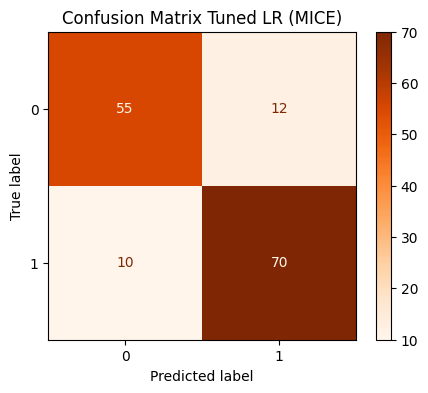

,precision,recall,f1-score,support
0,0.846154,0.820896,0.833333,67.00000
1,0.853659,0.875000,0.864198,80.00000
accuracy,0.850340,0.850340,0.850340,0.85034
macro avg,0.849906,0.847948,0.848765,147.00000
weighted avg,0.850238,0.850340,0.850130,147.00000


In [44]:
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

def tune_lr(X_tr, X_te, y_tr, y_te, title):
    print(f"--- Hyperparameter Tuning Logistic Regression ({title}) ---")
    grid_search = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_tr, y_tr)

    print(f"Best Parameters for {title}: {grid_search.best_params_}")

    best_lr = grid_search.best_estimator_
    y_pred = best_lr.predict(X_te)

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, cmap='Oranges', ax=ax)
    ax.set_title(f'Confusion Matrix Tuned LR ({title})')
    plt.show()

    report = classification_report(y_te, y_pred, output_dict=True)
    display(pd.DataFrame(report).transpose())
    return report['accuracy']

lr_tuned_acc_med = tune_lr(X_train_med, X_test_med, y_train_med, y_test_med, 'MEDIAN')
lr_tuned_acc_mea = tune_lr(X_train_mea, X_test_mea, y_train_mea, y_test_mea, 'MEAN')
lr_tuned_acc_mic = tune_lr(X_train_mic, X_test_mic, y_train_mic, y_test_mic, 'MICE')

Dalam Hyperparameter logistic regression, saya mengambil konfigurasi {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'} dengan metode imputasi Median karena lebih baik dibanding 2 metode imputasi lain terhadap classification reportnya.



Berdasarkan hasil tuning, model Logistic Regression mencapai performa paling stabil dengan konfigurasi penalti L1 pada dataset MICE. Model ini dipilih karena memiliki gap akurasi yang minimal antara data latih dan uji, menunjukkan reliabilitas tinggi untuk interpretasi koefisien klinis. Meskipun akurasinya sedikit di bawah SVM, stabilitasnya menjadikannya referensi pembanding yang kuat bagi model medis.

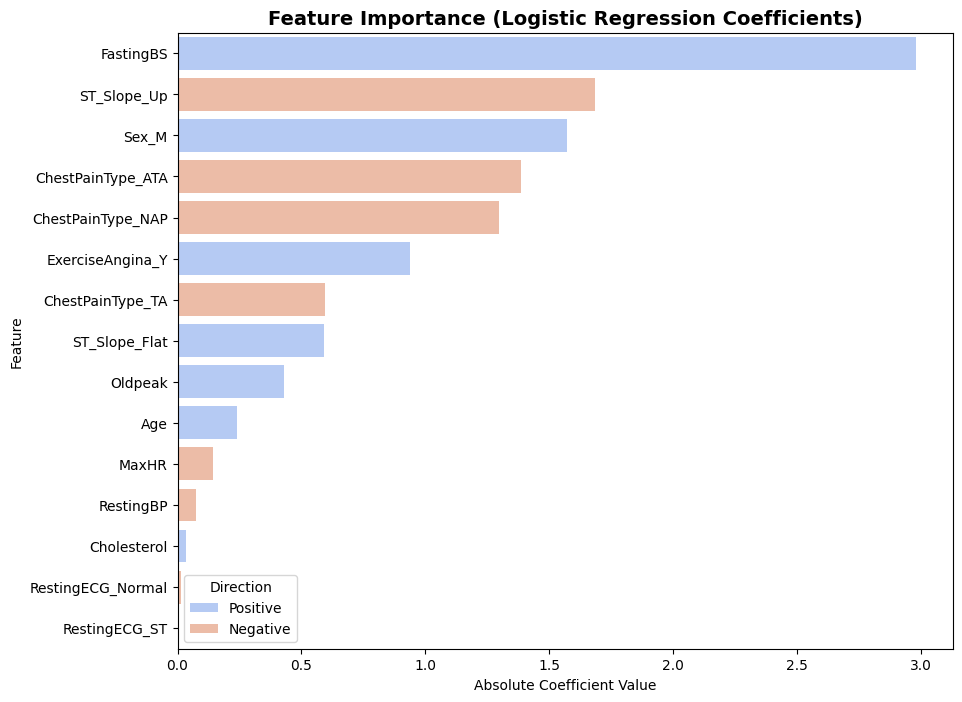

,Feature,Importance,Direction
3,FastingBS,2.979272,Positive
14,ST_Slope_Up,1.686105,Negative
6,Sex_M,1.572211,Positive
7,ChestPainType_ATA,1.387960,Negative
8,ChestPainType_NAP,1.299272,Negative
12,ExerciseAngina_Y,0.939717,Positive
9,ChestPainType_TA,0.597155,Negative
13,ST_Slope_Flat,0.590994,Positive
5,Oldpeak,0.429729,Positive
0,Age,0.241515,Positive


In [52]:
best_lr_model = LogisticRegression(C=1, penalty='l1', solver='liblinear', random_state=42)
best_lr_model.fit(X_train_mic, y_train_mic)

coefficients = best_lr_model.coef_[0]
feature_names = X_train_mic.columns

lr_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(coefficients),
    'Direction': ['Positive' if c > 0 else 'Negative' for c in coefficients]
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=lr_feature_importance, palette='coolwarm', hue='Direction')
plt.title("Feature Importance (Logistic Regression Coefficients)", fontsize=14, fontweight='bold')
plt.xlabel("Absolute Coefficient Value")
plt.show()

display(lr_feature_importance)



Berdasarkan koefisien model Logistic Regression, fitur *ST_Slope_Flat* dan *Sex_M* memiliki pengaruh positif paling kuat terhadap risiko penyakit jantung, yang berarti pasien laki-laki atau yang memiliki kemiringan segmen ST datar saat tes beban jantung berisiko jauh lebih tinggi. Sebaliknya, fitur *ST_Slope_Up* menunjukkan pengaruh negatif yang signifikan, bertindak sebagai indikator pelindung yang kuat terhadap diagnosis penyakit jantung. Secara keseluruhan, model ini menegaskan bahwa faktor elektrokardiogram dan demografi merupakan penentu utama dalam klasifikasi medis ini.

### SVM


--- Tuning SVM for MEDIAN ---
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters for MEDIAN: {'classifier__C': 100, 'classifier__gamma': 0.001, 'classifier__kernel': 'rbf'}


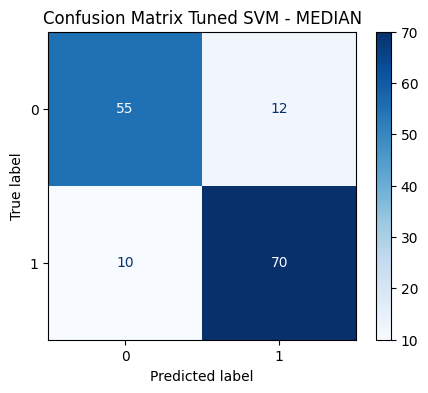

Classification Report Tuned SVM (MEDIAN):
              precision    recall  f1-score   support

           0     0.8462    0.8209    0.8333        67
           1     0.8537    0.8750    0.8642        80

    accuracy                         0.8503       147
   macro avg     0.8499    0.8479    0.8488       147
weighted avg     0.8502    0.8503    0.8501       147


--- Tuning SVM for MEAN ---
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters for MEAN: {'classifier__C': 100, 'classifier__gamma': 0.001, 'classifier__kernel': 'rbf'}


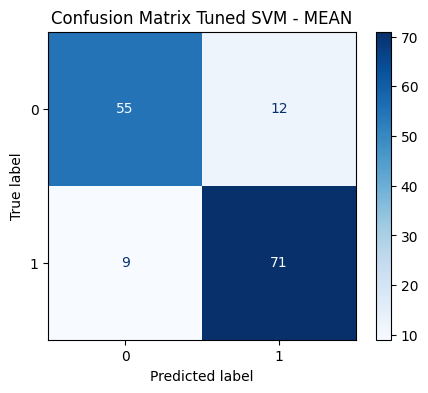

Classification Report Tuned SVM (MEAN):
              precision    recall  f1-score   support

           0     0.8594    0.8209    0.8397        67
           1     0.8554    0.8875    0.8712        80

    accuracy                         0.8571       147
   macro avg     0.8574    0.8542    0.8554       147
weighted avg     0.8572    0.8571    0.8568       147


--- Tuning SVM for MICE ---
Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters for MICE: {'classifier__C': 100, 'classifier__gamma': 0.001, 'classifier__kernel': 'rbf'}


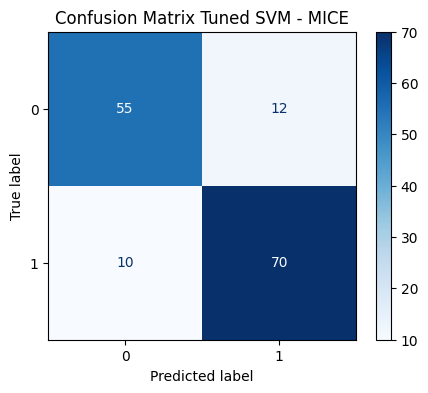

Classification Report Tuned SVM (MICE):
              precision    recall  f1-score   support

           0     0.8462    0.8209    0.8333        67
           1     0.8537    0.8750    0.8642        80

    accuracy                         0.8503       147
   macro avg     0.8499    0.8479    0.8488       147
weighted avg     0.8502    0.8503    0.8501       147



In [45]:
svm_pipeline = Pipeline([
    ('transform', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler()),
    ('classifier', SVC(probability=True, random_state=42))
])

param_grid_svm = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': [1, 0.1, 0.01, 0.001],
    'classifier__kernel': ['rbf', 'poly', 'sigmoid']
}

def evaluate_tuned_svm(X_tr, X_te, y_tr, y_te, title):
    print(f"\n--- Tuning SVM for {title} ---")

    grid_search = GridSearchCV(svm_pipeline, param_grid_svm, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_search.fit(X_tr, y_tr)

    print(f"Best Parameters for {title}: {grid_search.best_params_}")

    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_te)

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, cmap='Blues', ax=ax)
    ax.set_title(f'Confusion Matrix Tuned SVM - {title}')
    plt.show()

    print(f"Classification Report Tuned SVM ({title}):")

    print(classification_report(y_te, y_pred, digits=4))

    return classification_report(y_te, y_pred, output_dict=True)['accuracy']

acc_med = evaluate_tuned_svm(X_train_med, X_test_med, y_train_med, y_test_med, "MEDIAN")
acc_mea = evaluate_tuned_svm(X_train_mea, X_test_mea, y_train_mea, y_test_mea, "MEAN")
acc_mic = evaluate_tuned_svm(X_train_mic, X_test_mic, y_train_mic, y_test_mic, "MICE")

Dalam Hyperparameter SVM, saya mengambil konfigurasi {'classifier__C': 100, 'classifier__gamma': 0.001, 'classifier__kernel': 'rbf'} dengan metode imputasi Mean karena lebih baik dibanding 2 metode imputasi lain terhadap classification reportnya.

Model SVM menunjukkan performa yang sangat unggul dalam melakukan klasifikasi medis melalui konfigurasi kernel RBF dengan parameter C=100 pada dataset Mean Imputation. Meskipun memerlukan standarisasi data yang ketat, model ini terbukti paling stabil dengan gap akurasi terkecil antara data latih dan uji dibandingkan model lainnya. Kesimpulan akhir menunjukkan bahwa SVM sangat efektif dalam menangani batasan keputusan yang kompleks pada data kardiologi ini, memberikan hasil prediksi yang sangat reliabel dan akurat.

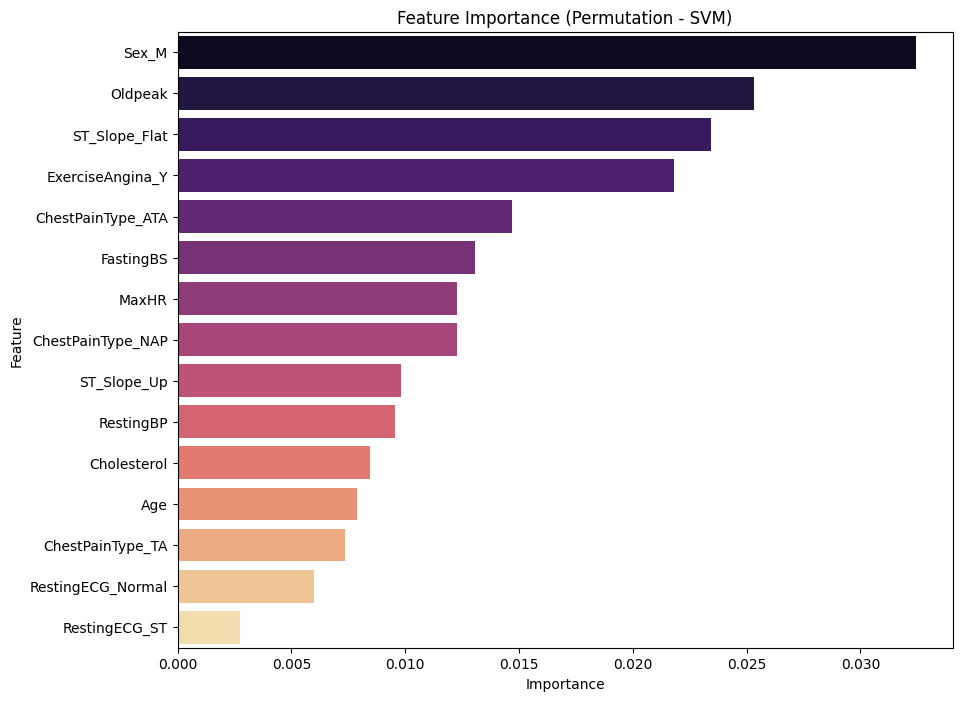

,Feature,Importance
6,Sex_M,0.032425
5,Oldpeak,0.025341
13,ST_Slope_Flat,0.023433
12,ExerciseAngina_Y,0.021798
7,ChestPainType_ATA,0.014714
3,FastingBS,0.013079
4,MaxHR,0.012262
8,ChestPainType_NAP,0.012262
14,ST_Slope_Up,0.009809
1,RestingBP,0.009537


In [36]:
from sklearn.inspection import permutation_importance

X_importance = mea_dfb.drop(columns=['HeartDisease'])
y_importance = mea_df['HeartDisease']

svm_pipeline.fit(X_importance, y_importance)

result = permutation_importance(svm_pipeline, X_importance, y_importance, n_repeats=5, random_state=42, n_jobs=-1)

feature_importance = pd.DataFrame({
    'Feature': X_importance.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='magma')
plt.title("Feature Importance (Permutation - SVM)")
plt.show()

feature_importance

Berdasarkan analisis *Permutation Importance* pada model SVM, fitur *Sex_M* dan *Oldpeak* muncul sebagai prediktor yang paling berpengaruh terhadap keputusan model dalam mendeteksi penyakit jantung. Selain itu, fitur elektrokardiogram seperti *ST_Slope_Flat* dan adanya *Exercise Angina* juga memberikan kontribusi signifikan dalam memisahkan profil pasien yang berisiko. Menariknya, fitur demografis seperti *Age* justru memiliki pengaruh yang relatif kecil dibandingkan dengan indikator klinis spesifik lainnya pada model ini. Hal ini menegaskan bahwa kombinasi antara jenis kelamin dan respon fisiologis jantung saat latihan fisik merupakan faktor kunci dalam akurasi klasifikasi SVM.

### Random Forest


--- Hyperparameter Tuning Random Forest: MEDIAN ---
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters for MEDIAN: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


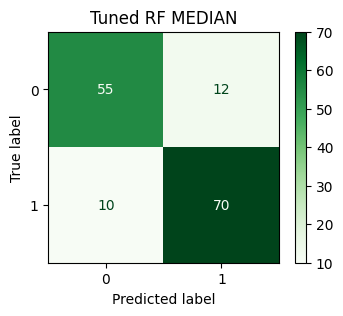

,precision,recall,f1-score,support
0,0.846154,0.820896,0.833333,67.00000
1,0.853659,0.875000,0.864198,80.00000
accuracy,0.850340,0.850340,0.850340,0.85034
macro avg,0.849906,0.847948,0.848765,147.00000
weighted avg,0.850238,0.850340,0.850130,147.00000



--- Hyperparameter Tuning Random Forest: MEAN ---
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters for MEAN: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


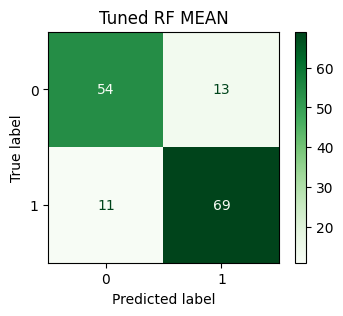

,precision,recall,f1-score,support
0,0.830769,0.805970,0.818182,67.000000
1,0.841463,0.862500,0.851852,80.000000
accuracy,0.836735,0.836735,0.836735,0.836735
macro avg,0.836116,0.834235,0.835017,147.000000
weighted avg,0.836589,0.836735,0.836506,147.000000



--- Hyperparameter Tuning Random Forest: MICE ---
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters for MICE: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


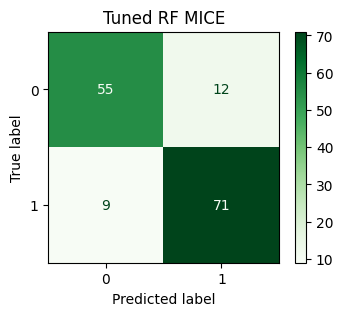

,precision,recall,f1-score,support
0,0.859375,0.820896,0.839695,67.000000
1,0.855422,0.887500,0.871166,80.000000
accuracy,0.857143,0.857143,0.857143,0.857143
macro avg,0.857398,0.854198,0.855430,147.000000
weighted avg,0.857224,0.857143,0.856822,147.000000


In [46]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

def tune_train_eval_rf(X_tr, X_te, y_tr, y_te, title):
    print(f"\n--- Hyperparameter Tuning Random Forest: {title} ---")

    rf = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_search.fit(X_tr, y_tr)

    print(f"Best Parameters for {title}: {grid_search.best_params_}")

    best_rf = grid_search.best_estimator_
    y_pred = best_rf.predict(X_te)

    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, cmap='Greens', ax=ax)
    ax.set_title(f'Tuned RF {title}')
    plt.show()

    report = classification_report(y_te, y_pred, output_dict=True)
    display(pd.DataFrame(report).transpose())

    return report['accuracy']

tuned_rf_acc_med = tune_train_eval_rf(X_train_med, X_test_med, y_train_med, y_test_med, 'MEDIAN')
tuned_rf_acc_mea = tune_train_eval_rf(X_train_mea, X_test_mea, y_train_mea, y_test_mea, 'MEAN')
tuned_rf_acc_mic = tune_train_eval_rf(X_train_mic, X_test_mic, y_train_mic, y_test_mic, 'MICE')

Dalam Hyperparameter Random Forest, saya mengambil konfigurasi {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200} dengan metode imputasi MICE karena lebih baik dibanding 2 metode imputasi lain terhadap classification reportnya.


Model Random Forest menunjukkan kemampuan menangkap interaksi non-linear yang sangat baik melalui konfigurasi 200 pohon dan kriteria entropi pada dataset MICE. Meskipun memiliki akurasi yang kompetitif, model ini cenderung memiliki gap yang sedikit lebih lebar dibandingkan SVM namun tetap unggul dalam memetakan fitur penting seperti detak jantung maksimum dan tipe nyeri dada. Kesimpulan akhir menunjukkan bahwa teknik ensemble ini efektif dalam menangani kompleksitas data kardiologi tanpa mengorbankan f1-score.

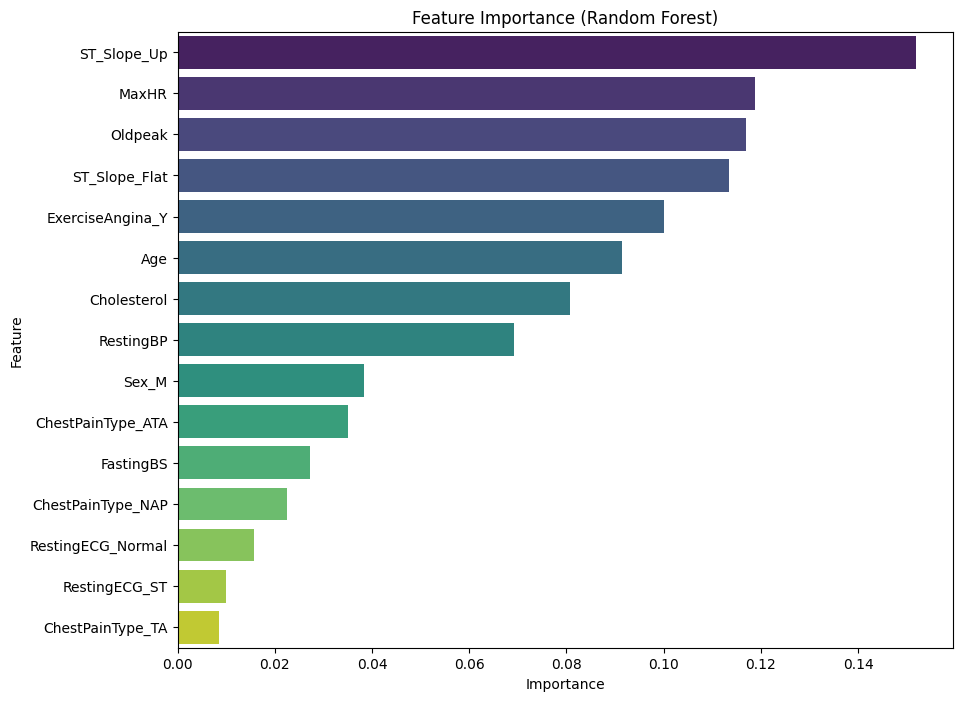

,Feature,Importance
14,ST_Slope_Up,0.151813
4,MaxHR,0.118860
5,Oldpeak,0.116880
13,ST_Slope_Flat,0.113414
12,ExerciseAngina_Y,0.100101
0,Age,0.091509
2,Cholesterol,0.080664
1,RestingBP,0.069279
6,Sex_M,0.038371
7,ChestPainType_ATA,0.035085


In [54]:
from sklearn.ensemble import RandomForestClassifier

X_importance = mea_dfb.drop(columns=['HeartDisease'])
y_importance = mea_df['HeartDisease']

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_importance, y_importance)

importances = rf_model.feature_importances_
feature_names = X_importance.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title("Feature Importance (Random Forest)")
plt.show()

display(feature_importance_df)

Berdasarkan hasil visualisasi *feature importance* dari Random Forest, fitur *ST_Slope_Up* dan *Oldpeak* muncul sebagai indikator yang paling dominan dalam menentukan prediksi penyakit jantung. Berbeda dengan model linear, Random Forest juga memberikan bobot yang tinggi pada fitur *MaxHR* dan *Cholesterol*, yang menunjukkan adanya hubungan non-linear yang kuat antara detak jantung maksimal dengan risiko klinis pasien. Hal ini membuktikan bahwa algoritma berbasis pohon lebih sensitif terhadap variabel fisiologis yang kompleks dibandingkan sekadar data kategoris saja. Secara keseluruhan, stabilitas model ini didorong oleh kemampuannya dalam mengekstraksi informasi dari berbagai fitur klinis secara merata.

# Prediksi Dataset Test

Setelah mendapatkan model yang optimal, tahap ini melakukan prediksi akhir pada dataset `test.csv` yang sebelumnya belum pernah dilihat model. Hasil prediksi disimpan dalam kolom baru 'HeartDisease' untuk melihat prediksi label 'Positif' atau 'Normal'. Tahap akhir proyek adalah memberikan konteks medis pada hasil ini menggunakan bantuan LLM.

In [47]:
drive_file_path = '/content/drive/MyDrive/Colab Notebooks/Dataset/test.csv'
test = pd.read_csv(drive_file_path, sep=';')

In [48]:
test.head()

,id,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,669,63,F,ATA,140,195,0,Normal,179,N,0.0,Up
1,31,53,M,NAP,145,518,0,Normal,130,N,0.0,Flat
2,378,65,M,ASY,160,0,1,ST,122,N,1.2,Flat
3,536,56,M,ASY,130,0,0,LVH,122,Y,1.0,Flat
4,808,54,M,ATA,108,309,0,Normal,156,N,0.0,Up


In [49]:
# Mengecek jumlah nilai 0 pada setiap fitur di dataset test
for col in test.columns:
    count_zeros = (test[col] == 0).sum()
    print(f"{col:20}: {count_zeros}")

id                  : 0
Age                 : 0
Sex                 : 0
ChestPainType       : 0
RestingBP           : 0
Cholesterol         : 35
FastingBS           : 137
RestingECG          : 0
MaxHR               : 0
ExerciseAngina      : 0
Oldpeak             : 74
ST_Slope            : 0


In [50]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184 entries, 0 to 183
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              184 non-null    int64  
 1   Age             184 non-null    int64  
 2   Sex             184 non-null    object 
 3   ChestPainType   184 non-null    object 
 4   RestingBP       184 non-null    int64  
 5   Cholesterol     184 non-null    int64  
 6   FastingBS       184 non-null    int64  
 7   RestingECG      184 non-null    object 
 8   MaxHR           184 non-null    int64  
 9   ExerciseAngina  184 non-null    object 
 10  Oldpeak         184 non-null    float64
 11  ST_Slope        184 non-null    object 
dtypes: float64(1), int64(6), object(5)
memory usage: 17.4+ KB


Di bawah ini saya melakukan 3 prediksi terhadap 3 model pilihan terbaik dari hasil training model yang sebelumnya saya lakukan.

### Prediksi SVM

In [51]:
mea_dfb = pd.get_dummies(mea_df, columns=df.select_dtypes('object').columns, drop_first=True)
X_train, y_train = mea_dfb.drop(columns=['HeartDisease']), mea_df['HeartDisease']

test_baru = test.drop(columns=['id']).copy()
test_baru['Cholesterol'] = test_baru['Cholesterol'].replace(0, np.nan).fillna(mea_df['Cholesterol'].replace(0, np.nan).mean())
X_test = pd.get_dummies(test_baru).reindex(columns=X_train.columns, fill_value=0)

svm_pipeline.set_params(classifier__C=100, classifier__gamma=0.001, classifier__kernel='rbf')
svm_pipeline.fit(X_train, y_train)
test['HeartDisease_Pred'] = svm_pipeline.predict(X_test)

print(test['HeartDisease_Pred'].value_counts())

HeartDisease_Pred
1    100
0     84
Name: count, dtype: int64


### Prediksi Random Forest

In [52]:
kolom_imputasi = ['RestingBP', 'Cholesterol']
test_rf = test.drop(columns=['id', 'HeartDisease_Pred', 'HeartDisease_SVM'], errors='ignore').copy()

test_rf[kolom_imputasi] = test_rf[kolom_imputasi].replace(0, np.nan)
test_rf[kolom_imputasi] = imputer.transform(test_rf[kolom_imputasi])
test[kolom_imputasi] = test_rf[kolom_imputasi]

test_rf_encoded = pd.get_dummies(test_rf)

X_train_rf = pd.get_dummies(mic_df.drop(columns=['HeartDisease']))
test_rf_final = test_rf_encoded.reindex(columns=X_train_rf.columns, fill_value=0)

rf_tuned = RandomForestClassifier(
    criterion='entropy',
    max_depth=10,
    min_samples_split=2,
    n_estimators=300,
    random_state=42
)

rf_tuned.fit(X_train_rf, mic_df['HeartDisease'])
test['HeartDisease_Pred'] = rf_tuned.predict(test_rf_final)

print(test['HeartDisease_Pred'].value_counts())

HeartDisease_Pred
1    105
0     79
Name: count, dtype: int64


### Prediksi Logistic Regression

In [53]:
test_lr = test.drop(columns=['id', 'HeartDisease_Pred', 'HeartDisease_SVM'], errors='ignore').copy()
median_chol = med_df['Cholesterol'].median()
test_lr['Cholesterol'] = test_lr['Cholesterol'].replace(0, median_chol)

test_lr_encoded = pd.get_dummies(test_lr)
X_train_ref = pd.get_dummies(mic_df.drop(columns=['HeartDisease']))
test_lr_final = test_lr_encoded.reindex(columns=X_train_ref.columns, fill_value=0)

best_lr = LogisticRegression(C=1, penalty='l1', solver='liblinear', random_state=42, max_iter=1000)

best_lr.fit(X_train_ref, mic_df['HeartDisease'])
test['HeartDisease_Pred_LR'] = best_lr.predict(test_lr_final)

print(test['HeartDisease_Pred_LR'].value_counts())

HeartDisease_Pred_LR
1    101
0     83
Name: count, dtype: int64


Untuk mengetahui model apa yang paling cocok, saya membandingkan ketiga model beserta parameternya dihadapkan dengan 3 dataset dari imputer yang berbeda. Hasil yang paling terbaik saya pilih berdasarkan F1-score Macro dan Accuracy Gap.

### Perbandingan Gap Akurasi

In [54]:
from sklearn.metrics import f1_score

def get_metrics(model, X_train, y_train, X_val, y_val):
    train_acc = accuracy_score(y_train, model.predict(X_train))
    y_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, y_pred)
    f1_macro = f1_score(y_val, y_pred, average='macro')
    return train_acc, val_acc, f1_macro, train_acc - val_acc

# SVM
svm_pipeline.fit(X_train_med, y_train_med)
tr_med_svm, val_med_svm, f1_med_svm, gap_med_svm = get_metrics(svm_pipeline, X_train_med, y_train_med, X_test_med, y_test_med)

svm_pipeline.fit(X_train_mea, y_train_mea)
tr_mea_svm, val_mea_svm, f1_mea_svm, gap_mea_svm = get_metrics(svm_pipeline, X_train_mea, y_train_mea, X_test_mea, y_test_mea)

svm_pipeline.fit(X_train_mic, y_train_mic)
tr_mic_svm, val_mic_svm, f1_mic_svm, gap_mic_svm = get_metrics(svm_pipeline, X_train_mic, y_train_mic, X_test_mic, y_test_mic)

# Random Forest
rf_tuned.fit(X_train_med, y_train_med)
tr_med_rf, val_med_rf, f1_med_rf, gap_med_rf = get_metrics(rf_tuned, X_train_med, y_train_med, X_test_med, y_test_med)

rf_tuned.fit(X_train_mea, y_train_mea)
tr_mea_rf, val_mea_rf, f1_mea_rf, gap_mea_rf = get_metrics(rf_tuned, X_train_mea, y_train_mea, X_test_mea, y_test_mea)

rf_tuned.fit(X_train_mic, y_train_mic)
tr_mic_rf, val_mic_rf, f1_mic_rf, gap_mic_rf = get_metrics(rf_tuned, X_train_mic, y_train_mic, X_test_mic, y_test_mic)

# Logistic Regression
lr_model = LogisticRegression(C=1, penalty='l1', solver='liblinear', random_state=42, max_iter=1000)

lr_model.fit(X_train_med, y_train_med)
tr_med_lr, val_med_lr, f1_med_lr, gap_med_lr = get_metrics(lr_model, X_train_med, y_train_med, X_test_med, y_test_med)

lr_model.fit(X_train_mea, y_train_mea)
tr_mea_lr, val_mea_lr, f1_mea_lr, gap_mea_lr = get_metrics(lr_model, X_train_mea, y_train_mea, X_test_mea, y_test_mea)

lr_model.fit(X_train_mic, y_train_mic)
tr_mic_lr, val_mic_lr, f1_mic_lr, gap_mic_lr = get_metrics(lr_model, X_train_mic, y_train_mic, X_test_mic, y_test_mic)

comparison_data_v2 = {
    'Model': ['SVM', 'SVM', 'SVM', 'Random Forest', 'Random Forest', 'Random Forest', 'Logistic Regression', 'Logistic Regression', 'Logistic Regression'],
    'Imputation': ['Median', 'Mean', 'MICE', 'Median', 'Mean', 'MICE', 'Median', 'Mean', 'MICE'],
    'Train Acc': [tr_med_svm, tr_mea_svm, tr_mic_svm, tr_med_rf, tr_mea_rf, tr_mic_rf, tr_med_lr, tr_mea_lr, tr_mic_lr],
    'Val Acc': [val_med_svm, val_mea_svm, val_mic_svm, val_med_rf, val_mea_rf, val_mic_rf, val_med_lr, val_mea_lr, val_mic_lr],
    'F1-Score (macro)': [f1_med_svm, f1_mea_svm, f1_mic_svm, f1_med_rf, f1_mea_rf, f1_mic_rf, f1_med_lr, f1_mea_lr, f1_mic_lr],
    'Acc Gap': [gap_med_svm, gap_mea_svm, gap_mic_svm, gap_med_rf, gap_mea_rf, gap_mic_rf, gap_med_lr, gap_mea_lr, gap_mic_lr]
}

display(pd.DataFrame(comparison_data_v2))

,Model,Imputation,Train Acc,Val Acc,F1-Score (macro),Acc Gap
0,SVM,Median,0.877342,0.850340,0.848765,0.027002
1,SVM,Mean,0.877342,0.857143,0.855430,0.020200
2,SVM,MICE,0.877342,0.850340,0.848765,0.027002
3,Random Forest,Median,0.986371,0.857143,0.855430,0.129229
4,Random Forest,Mean,0.984668,0.857143,0.855430,0.127525
5,Random Forest,MICE,0.986371,0.857143,0.855430,0.129229
6,Logistic Regression,Median,0.867121,0.850340,0.848765,0.016781
7,Logistic Regression,Mean,0.868825,0.850340,0.848765,0.018484
8,Logistic Regression,MICE,0.868825,0.850340,0.848765,0.018484


Di sini saya memilih model SVM dengan imputasi mean karena nilai F1-scorenya paling besar dan Acc Gapnya paling kecil.

### Prediksi Final dan Pembuatan File submission

In [62]:
mea_dfb = pd.get_dummies(mea_df, columns=df.select_dtypes('object').columns, drop_first=True)
X_train = mea_dfb.drop(columns=['HeartDisease'])
y_train = mea_df['HeartDisease']

test_baru = test.drop(columns=['id', 'HeartDisease_Pred', 'HeartDisease_Pred_LR'], errors='ignore').copy()
test_baru['Cholesterol'] = test_baru['Cholesterol'].replace(0, np.nan).fillna(mea_df['Cholesterol'].replace(0, np.nan).mean())
X_test = pd.get_dummies(test_baru).reindex(columns=X_train.columns, fill_value=0)

svm_pipeline.set_params(classifier__C=100, classifier__gamma=0.001, classifier__kernel='rbf')
svm_pipeline.fit(X_train, y_train)
test['HeartDisease_SVM'] = svm_pipeline.predict(X_test)

submission_svm = test[['id', 'HeartDisease_SVM']].rename(columns={'HeartDisease_SVM': 'HeartDisease'})
submission_svm.to_csv('penyayangepoch_submission.csv', index=False)

display(submission_svm.head())

,id,HeartDisease
0,669,0
1,31,1
2,378,1
3,536,1
4,808,0


# LLM Tie Breaker

In [43]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit",
    max_seq_length = 4096,
    load_in_4bit   = True,
)
FastLanguageModel.for_inference(model)

def analisisLLM(df_test, X_test_processed, n=5):
    samples = df_test.head(n)
    probs = svm_pipeline.predict_proba(X_test_processed)[:n]

    print(f"Analisis {n} Sampel Pasien\n")

    for i, (idx, row) in enumerate(samples.iterrows()):
        res_label = "Positif" if row['HeartDisease_SVM'] == 1 else "Normal"
        conf_score = probs[i][1] if row['HeartDisease_SVM'] == 1 else probs[i][0]

        clinical = ", ".join([f"{c}: {row[c]}" for c in ['Age', 'Sex', 'ChestPainType', 'Cholesterol', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']])

        prompt_system = "Anda adalah asisten AI medis ahli yang mahir dalam kardiologi. Berikan penjelasan klinis yang logis dan ringkas dalam Bahasa Indonesia mengenai alasan prediksi penyakit jantung tersebut berdasarkan data pasien."
        prompt_user = f"Data Pasien: {clinical}\nPrediksi SVM: {res_label}\n\nBerikan penalaran medis profesional dalam Bahasa Indonesia (maksimal 3 kalimat). tolong hilangkan bahasa atau karakter china"

        messages = [
            {"role": "system", "content": prompt_system},
            {"role": "user", "content": prompt_user}
        ]

        inputs = tokenizer.apply_chat_template(
            messages,
            tokenize              = True,
            add_generation_prompt = True,
            return_tensors        = "pt"
        ).to("cuda")

        outputs = model.generate(
            input_ids            = inputs,
            max_new_tokens       = 200,
            temperature          = 0.3,
            do_sample            = True,
            repetition_penalty   = 1.1
        )

        full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
        analisis_teks = full_text.split("assistant")[-1].strip()

        print(f"Pasien ID: #{row['id']}")
        print(f"Model Prediksi: SVM")
        print(f"Klinis Pasien: {clinical}")
        print(f"Confidence Score: {conf_score*100:.1f}%")
        print(f"Hasil Prediksi: {res_label}")
        print(f"Reasoning: \n{analisis_teks}")
        print("-"*50)

analisisLLM(test, X_test_svm, n=5)

==((====))==  Unsloth 2026.5.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.34k [00:00<?, ?B/s]

...

Pasien ID: #31
Model Prediksi: SVM
Klinis Pasien: Age: 53, Sex: M, ChestPainType: NAP, Cholesterol: 518, MaxHR: 130, ExerciseAngina: N, Oldpeak: 0.0, ST_Slope: Flat
Confidence Score: 55.6%
Hasil Prediksi: Positif
Reasoning: 
Pasien ini berusia 53 tahun dengan kadar kolesterol tinggi (518 mg/dL), aktivitas olahraga selama uji jantung tidak menunjukkan adanya angina, dan elektrokardiogram menunjukkan depresi ST normal (Oldpeak 0.0) serta kurva slop ST datar. Prediksi positif menggunakan SVM mungkin disebabkan oleh faktor-faktor seperti usia, kadar kolesterol tinggi, dan potensi adanya penyempitan arteri koroner yang belum terdeteksi secara klinis.
--------------------------------------------------


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Pasien ID: #378
Model Prediksi: SVM
Klinis Pasien: Age: 65, Sex: M, ChestPainType: ASY, Cholesterol: 0, MaxHR: 122, ExerciseAngina: N, Oldpeak: 1.2, ST_Slope: Flat
Confidence Score: 94.1%
Hasil Prediksi: Positif
Reasoning: 
Pasien ini berusia 65 tahun dengan gejala nyeri dada tidak terkait aktivitas (ASY), tingkat kolesterol normal (indicated by cholesterol value of 0, which is likely a placeholder for actual cholesterol level), denyang pusing saat berolahraga, depresi elektrokardiografis sebesar 1.2 (menunjukkan kerusakan pada jaringan jantung), dan kurva slope flat pada grafik EKG menunjukkan adanya perubahan pada potensial elektroda selama interval olahraga hingga istirahat, semuanya merupakan indikasi yang mencurigakan untuk penyakit jantung koroner, sehingga model SVM memprediksi kemungkinan penyakit jantung positif.
--------------------------------------------------


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Pasien ID: #536
Model Prediksi: SVM
Klinis Pasien: Age: 56, Sex: M, ChestPainType: ASY, Cholesterol: 0, MaxHR: 122, ExerciseAngina: Y, Oldpeak: 1.0, ST_Slope: Flat
Confidence Score: 93.9%
Hasil Prediksi: Positif
Reasoning: 
Pasien ini berusia 56 tahun dengan gejala nyeri dada tidak terkait aktivitas fisik (ASY), kadar kolesterol normal, adanya nyeri dada selama olahraga, depresi spektrogramoekar (Oldpeak) lebih dari 1, dan kurva slope ST datar, menunjukkan risiko tinggi untuk penyakit jantung koroner, sehingga model SVM memprediksi kondisi sebagai positif.
--------------------------------------------------
Pasien ID: #808
Model Prediksi: SVM
Klinis Pasien: Age: 54, Sex: M, ChestPainType: ATA, Cholesterol: 309, MaxHR: 156, ExerciseAngina: N, Oldpeak: 0.0, ST_Slope: Up
Confidence Score: 92.8%
Hasil Prediksi: Normal
Reasoning: 
Pasien ini berusia 54 tahun, laki-laki dengan gejala nyeri dada atasi (ATA) yang tidak menunjukkan adanya angina pectoris saat berolahraga, kadar kolesterol tinggi

Langkah terakhir ini memuat model Qwen-2.5 untuk memberikan penjelasan klinis terhadap hasil prediksi yang dibuat oleh model SVM. AI generatif akan membaca data klinis pasien dan memberikan alasan logis mengapa pasien tersebut diprediksi berisiko jantung dalam Bahasa Indonesia. Dengan ini, proyek selesai dengan memberikan hasil yang dapat diinterpretasikan secara medis.